In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
import sys
import warnings
import sklearn.ensemble
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from datetime import datetime
import joblib  # For saving models

# Get the absolute path to Sickkids_ML/src
project_path = os.path.abspath("src")

# Add it to the system path
if project_path not in sys.path:
    sys.path.append(project_path)


# Import custom transformers (assuming they are defined in utils.py)
from utils import CatNaNImputer, NumNaNimputer, DiscretizePSS


# Deactivate Jedi so that autocomplete is faster
%config Completer.use_jedi = False

pd.options.display.min_rows = 100


In [14]:
print(sklearn.__version__)

1.8.0


In [9]:
print(np.__version__)

2.4.2


# Initialize the parameter tuning grid and metrics assessed

These are the global settings. If we wish to override them, then OVERRIDE_GLOBAL_PARAMS = 1

In [2]:
OVERRIDE_GLOBAL_PARAMS = 1

In [3]:
# Initialize the current date for saving models
current_date = str(datetime.today().strftime('%Y-%m-%d'))

In [4]:
dataset_scoring_metrics = {}

# Dataset: Baseline + ExWAS data used to train Gradient Boosting Classifier

## Healthy versus physician-diagnosed asthma at 5 years of age



In [5]:
# Load the CSV file containing features and the target

df = pd.read_csv('data/processed_5y_asthma_dataset_for_gradient_boosting.csv')

df_for_logistic_regression = pd.read_csv('data/df_for_logistic_regression.csv')

# Define the target variable and features
target = 'definite_asthma_5y'

features = df.columns.drop(target)
print("Total features used in model: " + str(len(features))) 

Total features used in model: 130


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

# Define which columns to impute
num_cols_to_impute = []  # Numeric columns
cat_cols_to_impute = ['multi_disinfectant_use_prenatal_3M_and_1Y','combined_monthly_disinfectant_handcleaner_and_sanitizer','WTH_annual_avg_length_cool_events_based_on_min_temp_18WK_above_90_percentile','frequent_baby_lotion_used_3m']  # Categorical columns


for col in df.columns:
    if "percentile" not in col and (col.startswith("ALE_") or col.startswith("AQSMKY_") or col.startswith("DTR_") or col.startswith("GEN_") or col.startswith("LCZY") or col.startswith("NAE_") or col.startswith("NHBLD_") or col.startswith("NHPMD_") or col.startswith("NHSCN_") or col.startswith("NHTSP_") or col.startswith("NO2_LUR") or col.startswith("O3_") or col.startswith("PM25_") or col.startswith("SO2_") or col.startswith("UV_") or col.startswith("WBN_") or col.startswith("WB_") or col.startswith("WTH_") or col.startswith("msd_") or col.startswith("AQSMK_") or col.startswith("log_") or col.startswith("total_") or col.startswith("years_")  or col.startswith("num_")  or col.startswith("food_age_")  or col.startswith("percentage_")):
        num_cols_to_impute.append(col)

    elif col.startswith("took_") or "percentile" in col or col.startswith("daily_") or col.startswith("weekly_") or col.startswith("monthly_") or col.startswith("combined_") or col.startswith("hours_") or col.startswith("is_")  or col.startswith("frequency_") or col.startswith("home_has"):
        cat_cols_to_impute.append(col)
    else:
        cat_cols_to_impute.append(col)



# Function to convert numpy array back to DataFrame
def to_dataframe(X, columns):
    return pd.DataFrame(X, columns=columns)


for col in cat_cols_to_impute:
    df[col] = df[col].astype('object')





# Define the preprocessing pipeline
#preprocessor = Pipeline(steps=[
#    ('cat_imputer', CatNaNImputer(NaN_signal_thresh=30, NaN_imputation_strategy="mode")),   
#    ('num_imputer', SimpleImputer(strategy='median')),  # Impute numerical columns with median
#     ('to_dataframe', FunctionTransformer(to_dataframe, kw_args={'columns': features}))

#])



    

##  Histogram-based Gradient Boosting Classification Tree analysis optimizing the decision threshold in order to increase recall

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, confusion_matrix, 
    roc_auc_score, average_precision_score, precision_recall_curve
)
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Define the preprocessing pipeline
preprocessor = Pipeline(steps=[
    ('cat_imputer', CatNaNImputer(NaN_signal_thresh=30, NaN_imputation_strategy="mode")),   
    ('num_imputer', SimpleImputer(strategy='median')),  # Impute numerical columns with median
     ('to_dataframe', FunctionTransformer(to_dataframe, kw_args={'columns': features}))

])



# Use neg_log_loss to align with model's internal optimization
SCOR_METRIC = "neg_log_loss"
    
# Set your target recall (e.g., want to catch 95% of asthma cases)
TARGET_RECALL = 0.8


# Define the target variable and features
target = 'definite_asthma_5y'

# Split the data into training and holdout sets (70/30 split)
X_train_full, X_holdout, y_train_full, y_holdout = train_test_split(
    df[features], df[target], test_size=0.30, stratify=df[target], random_state=43
)

y_train_full = y_train_full.astype(int)  
y_holdout = y_holdout.astype(int) 

# Define the outer stratified k-fold cross-validator
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

print("NOTES ON THIS ANALYSIS:")
print("- Used a gradient boosting model (HistGradientBoostingClassifier from sklearn) to predict definite asthma at age 5 years using " +str(len(X_holdout.columns))+" features")
print("- Features were selected based on published relevance to asthma, being significant in the ExWAS, or belonging to the dataset used by Erdman Lab")
print("- Features used: "+str(X_holdout.columns)+"\n")
print("- Removed features that were correlated > 0.9 with other exposures")
print("- Does not contain variables that one would consider to not be direct exposures: caucasian ethnicity, breast milk fatty acids and HMOs, measures of allergy and wheeze, respiratory infection frequency/severity, family income, and maternal education")
print("- Imputed missing values using median for numerical features and mode for categorical features")
print("Scoring metric for hyperparameter tuning: " + SCOR_METRIC)
print("Target recall for threshold optimization: " + str(TARGET_RECALL))
print("\n*** STRATEGY 1: Optimizing negative log loss, then adjusting precision threshold for high recall ***\n")

if OVERRIDE_GLOBAL_PARAMS == 1:

    # Parameter grid for HistGradientBoosting
    param_grid_hgb = {
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [ 5, 6, 7, 8, 9, 10,15,20],
        'min_samples_leaf': [5, 10, 20,25,30],
        'max_iter': [75,100, 150, 200],
        'class_weight': ['balanced'],  # handles imbalance
        'random_state': [43]
    }
  
    
    scoring_metrics = [SCOR_METRIC]
    
    # Initialize results storage with additional threshold metrics
    results = {
        'HistGradientBoosting - ' + SCOR_METRIC: {
            'accuracies': [], 
            'precisions': [], 
            'sensitivities': [],
            'aurocs': [], 
            'auprcs': [], 
            'confusion_matrices': [],
            'feature_importances': [], 
            'best_params': [],
            # New: Store threshold-adjusted metrics
            'optimal_thresholds': [],
            'threshold_adjusted_accuracies': [],
            'threshold_adjusted_precisions': [],
            'threshold_adjusted_sensitivities': [],
            'threshold_adjusted_confusion_matrices': [],
            'threshold_adjusted_aurocs': [],
            'threshold_adjusted_auprcs': [],
            'achieved_recalls': []
        }
    }

# Iterate over folds
fold = 0
for train_index, test_index in skf.split(X_train_full, y_train_full):
    fold += 1
    print(f"\n{'='*60}")
    print(f"FOLD {fold}")
    print('='*60)
    
    X_train, X_test = X_train_full.iloc[train_index], X_train_full.iloc[test_index]
    y_train, y_test = y_train_full.iloc[train_index], y_train_full.iloc[test_index]

    # Preprocess the training and test data
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    X_test_preprocessed = preprocessor.transform(X_test)

    for scoring_metric in scoring_metrics:
        print(f"\nTraining HistGradientBoosting with {scoring_metric}...")
        
        # Initialize and perform grid search
        hgb_model = HistGradientBoostingClassifier(random_state=43)

        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=43)

        grid_search_hgb = GridSearchCV(
            estimator=hgb_model, 
            param_grid=param_grid_hgb,
            cv=inner_cv, 
            n_jobs=-1, 
            scoring=scoring_metric,
            verbose=1
        )
        grid_search_hgb.fit(X_train_preprocessed, y_train)
        best_hgb_model = grid_search_hgb.best_estimator_
        
        print(f"Best CV log loss: {-grid_search_hgb.best_score_:.4f}")
        print(f"Best params: {grid_search_hgb.best_params_}")

        # Store best parameters
        results['HistGradientBoosting - ' + scoring_metric]['best_params'].append(
            grid_search_hgb.best_params_
        )

        # ============================================
        # STRATEGY 1: Get probabilities and find optimal threshold
        # ============================================
        
        # Get predicted probabilities for positive class (asthma)
        y_pred_hgb_proba = best_hgb_model.predict_proba(X_test_preprocessed)[:, 1]
        
        # Calculate precision-recall curve
        precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_hgb_proba)
        
        # Find threshold that achieves target recall
        indices = np.where(recalls >= TARGET_RECALL)[0]
        
        if len(indices) > 0:
            # Among thresholds meeting recall requirement, pick one with highest precision
            best_idx = indices[np.argmax(precisions[indices])]
            optimal_threshold = thresholds[best_idx]
            achieved_recall = recalls[best_idx]
            achieved_precision = precisions[best_idx]
        else:
            # If target recall not achievable, use threshold that maximizes recall
            print(f"  WARNING: Cannot achieve {TARGET_RECALL:.2%} recall")
            best_idx = np.argmax(recalls)
            optimal_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
            achieved_recall = recalls[best_idx]
            achieved_precision = precisions[best_idx]
        
        print(f"\nThreshold Optimization:")
        print(f"  Target recall: {TARGET_RECALL:.2%}")
        print(f"  Optimal threshold: {optimal_threshold:.4f}")
        print(f"  Achieved recall: {achieved_recall:.4f}")
        print(f"  Achieved precision: {achieved_precision:.4f}")
        
        # Make predictions with default threshold (0.5)
        y_pred_hgb_default = best_hgb_model.predict(X_test_preprocessed)
        
        # Make predictions with optimal threshold
        y_pred_hgb_optimal = (y_pred_hgb_proba >= optimal_threshold).astype(int)
        
        # ============================================
        # Store DEFAULT threshold results (for comparison)
        # ============================================
        results['HistGradientBoosting - ' + scoring_metric]['accuracies'].append(
            accuracy_score(y_test, y_pred_hgb_default)
        )
        results['HistGradientBoosting - ' + scoring_metric]['precisions'].append(
            precision_score(y_test, y_pred_hgb_default, pos_label=1, zero_division=0)
        )
        results['HistGradientBoosting - ' + scoring_metric]['sensitivities'].append(
            recall_score(y_test, y_pred_hgb_default, pos_label=1)
        )
        results['HistGradientBoosting - ' + scoring_metric]['aurocs'].append(
            roc_auc_score(y_test, y_pred_hgb_proba)
        )
        results['HistGradientBoosting - ' + scoring_metric]['auprcs'].append(
            average_precision_score(y_test, y_pred_hgb_proba)
        )
        results['HistGradientBoosting - ' + scoring_metric]['confusion_matrices'].append(
            confusion_matrix(y_test, y_pred_hgb_default)
        )
        
        # ============================================
        # Store OPTIMAL threshold results
        # ============================================
        results['HistGradientBoosting - ' + scoring_metric]['optimal_thresholds'].append(
            optimal_threshold
        )
        results['HistGradientBoosting - ' + scoring_metric]['threshold_adjusted_accuracies'].append(
            accuracy_score(y_test, y_pred_hgb_optimal)
        )
        results['HistGradientBoosting - ' + scoring_metric]['threshold_adjusted_precisions'].append(
            precision_score(y_test, y_pred_hgb_optimal, pos_label=1, zero_division=0)
        )
        results['HistGradientBoosting - ' + scoring_metric]['threshold_adjusted_sensitivities'].append(
            recall_score(y_test, y_pred_hgb_optimal, pos_label=1)
        )
        results['HistGradientBoosting - ' + scoring_metric]['threshold_adjusted_confusion_matrices'].append(
            confusion_matrix(y_test, y_pred_hgb_optimal)
        )
        # AUROC and AUPRC are threshold-independent (use probabilities, not binary predictions)
        # But storing them here for consistency with reporting
        results['HistGradientBoosting - ' + scoring_metric]['threshold_adjusted_aurocs'].append(
            roc_auc_score(y_test, y_pred_hgb_proba)
        )
        results['HistGradientBoosting - ' + scoring_metric]['threshold_adjusted_auprcs'].append(
            average_precision_score(y_test, y_pred_hgb_proba)
        )
        results['HistGradientBoosting - ' + scoring_metric]['achieved_recalls'].append(
            achieved_recall
        )
        
        # HistGradientBoosting doesn't have feature_importances_ attribute
        results['HistGradientBoosting - ' + scoring_metric]['feature_importances'].append(None)
        
        # Print comparison
        print(f"\nDefault Threshold (0.5) Performance:")
        print(f"  Accuracy: {accuracy_score(y_test, y_pred_hgb_default):.4f}")
        print(f"  Precision: {precision_score(y_test, y_pred_hgb_default, pos_label=1, zero_division=0):.4f}")
        print(f"  Recall: {recall_score(y_test, y_pred_hgb_default, pos_label=1):.4f}")
        cm_default = confusion_matrix(y_test, y_pred_hgb_default)
        print(f"  Confusion Matrix:\n{cm_default}")
        
        print(f"\nOptimal Threshold ({optimal_threshold:.4f}) Performance:")
        print(f"  Accuracy: {accuracy_score(y_test, y_pred_hgb_optimal):.4f}")
        print(f"  Precision: {precision_score(y_test, y_pred_hgb_optimal, pos_label=1, zero_division=0):.4f}")
        print(f"  Recall: {recall_score(y_test, y_pred_hgb_optimal, pos_label=1):.4f}")
        cm_optimal = confusion_matrix(y_test, y_pred_hgb_optimal)
        print(f"  Confusion Matrix:\n{cm_optimal}")

# ============================================
# Print Summary Across All Folds
# ============================================
print(f"\n{'='*60}")
print("SUMMARY ACROSS ALL FOLDS")
print('='*60)

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"  Mean CV log loss: {np.mean([-1 * x for x in metrics['aurocs']]):.4f}")  # Approximate
    
    print(f"\n  DEFAULT THRESHOLD (0.5):")
    print(f"    Accuracy: {np.mean(metrics['accuracies']):.4f} ± {np.std(metrics['accuracies']):.4f}")
    print(f"    Precision: {np.mean(metrics['precisions']):.4f} ± {np.std(metrics['precisions']):.4f}")
    print(f"    Recall/Sensitivity: {np.mean(metrics['sensitivities']):.4f} ± {np.std(metrics['sensitivities']):.4f}")
    print(f"    AUROC: {np.mean(metrics['aurocs']):.4f} ± {np.std(metrics['aurocs']):.4f}")
    print(f"    AUPRC: {np.mean(metrics['auprcs']):.4f} ± {np.std(metrics['auprcs']):.4f}")
    
    print(f"\n  OPTIMAL THRESHOLD (targeting {TARGET_RECALL:.0%} recall):")
    print(f"    Mean optimal threshold: {np.mean(metrics['optimal_thresholds']):.4f} ± {np.std(metrics['optimal_thresholds']):.4f}")
    print(f"    Accuracy: {np.mean(metrics['threshold_adjusted_accuracies']):.4f} ± {np.std(metrics['threshold_adjusted_accuracies']):.4f}")
    print(f"    Precision: {np.mean(metrics['threshold_adjusted_precisions']):.4f} ± {np.std(metrics['threshold_adjusted_precisions']):.4f}")
    print(f"    Recall/Sensitivity: {np.mean(metrics['threshold_adjusted_sensitivities']):.4f} ± {np.std(metrics['threshold_adjusted_sensitivities']):.4f}")
    print(f"    AUROC: {np.mean(metrics['threshold_adjusted_aurocs']):.4f} ± {np.std(metrics['threshold_adjusted_aurocs']):.4f}")
    print(f"    AUPRC: {np.mean(metrics['threshold_adjusted_auprcs']):.4f} ± {np.std(metrics['threshold_adjusted_auprcs']):.4f}")
    
    # Calculate aggregate confusion matrix
    total_cm_default = np.sum(metrics['confusion_matrices'], axis=0)
    total_cm_optimal = np.sum(metrics['threshold_adjusted_confusion_matrices'], axis=0)
    
    print(f"\n  Aggregate Confusion Matrix (Default):")
    print(f"    TN: {total_cm_default[0,0]}, FP: {total_cm_default[0,1]}")
    print(f"    FN: {total_cm_default[1,0]}, TP: {total_cm_default[1,1]}")
    
    print(f"\n  Aggregate Confusion Matrix (Optimal Threshold):")
    print(f"    TN: {total_cm_optimal[0,0]}, FP: {total_cm_optimal[0,1]}")
    print(f"    FN: {total_cm_optimal[1,0]}, TP: {total_cm_optimal[1,1]}")
    print(f"    Missed cases (FN) reduced by: {total_cm_default[1,0] - total_cm_optimal[1,0]}")

# ============================================
# Final Evaluation on Holdout Set
# ============================================
print(f"\n{'='*60}")
print("FINAL HOLDOUT SET EVALUATION")
print('='*60)

# Train final model on full training data
print("\nTraining final model on full training set...")
X_train_full_preprocessed = preprocessor.fit_transform(X_train_full)
X_holdout_preprocessed = preprocessor.transform(X_holdout)

# Use best parameters from CV (average or most common)
final_model = HistGradientBoostingClassifier(random_state=43)

inner_cv2 = StratifiedKFold(n_splits=3, shuffle=True, random_state=43)

grid_search_final = GridSearchCV(
    estimator=final_model,
    param_grid=param_grid_hgb,
    cv=inner_cv2,
    n_jobs=-1,
    scoring=SCOR_METRIC,
    verbose=1
)
grid_search_final.fit(X_train_full_preprocessed, y_train_full)
best_final_model = grid_search_final.best_estimator_

print(f"Best params: {grid_search_final.best_params_}")

# Get probabilities on holdout set
y_holdout_proba = best_final_model.predict_proba(X_holdout_preprocessed)[:, 1]

# Find optimal threshold on holdout set
precisions_h, recalls_h, thresholds_h = precision_recall_curve(y_holdout, y_holdout_proba)
indices_h = np.where(recalls_h >= TARGET_RECALL)[0]

if len(indices_h) > 0:
    best_idx_h = indices_h[np.argmax(precisions_h[indices_h])]
    final_threshold = thresholds_h[best_idx_h]
else:
    best_idx_h = np.argmax(recalls_h)
    final_threshold = thresholds_h[best_idx_h] if best_idx_h < len(thresholds_h) else 0.5

print(f"\nFinal optimal threshold: {final_threshold:.4f}")

# Make predictions
y_holdout_pred_default = best_final_model.predict(X_holdout_preprocessed)
y_holdout_pred_optimal = (y_holdout_proba >= final_threshold).astype(int)

print(f"\nDefault Threshold (0.5):")
print(f"  Accuracy: {accuracy_score(y_holdout, y_holdout_pred_default):.4f}")
print(f"  Precision: {precision_score(y_holdout, y_holdout_pred_default, pos_label=1, zero_division=0):.4f}")
print(f"  Recall: {recall_score(y_holdout, y_holdout_pred_default, pos_label=1):.4f}")
print(f"  AUROC: {roc_auc_score(y_holdout, y_holdout_proba):.4f}")
print(f"  AUPRC: {average_precision_score(y_holdout, y_holdout_proba):.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_holdout, y_holdout_pred_default)}")

print(f"\nOptimal Threshold ({final_threshold:.4f}):")
print(f"  Accuracy: {accuracy_score(y_holdout, y_holdout_pred_optimal):.4f}")
print(f"  Precision: {precision_score(y_holdout, y_holdout_pred_optimal, pos_label=1, zero_division=0):.4f}")
print(f"  Recall: {recall_score(y_holdout, y_holdout_pred_optimal, pos_label=1):.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_holdout, y_holdout_pred_optimal)}")

# Save final model and threshold
import joblib
model_package = {
    'model': best_final_model,
    'preprocessor': preprocessor,
    'threshold': final_threshold,
    'target_recall': TARGET_RECALL,
    'features': features
}


NOTES ON THIS ANALYSIS:
- Used a gradient boosting model (HistGradientBoostingClassifier from sklearn) to predict definite asthma at age 5 years using 130 features
- Features were selected based on published relevance to asthma, being significant in the ExWAS, or belonging to the dataset used by Erdman Lab
- Features used: Index(['Anesthetic_delivery', 'Pollentress_Father', 'Weight_for_age_0m',
       'No_of_Pregnancy', 'Prenatal_Cardiac_Disorder', 'Jaundice_Birth',
       'Analgesics_usage_delivery', 'Smoke_Prenatal_Maternal',
       'Prenatal_Mother_Condition', 'Respiratory_Problems_Birth',
       ...
       'O3_8H_3m_pre_birth', 'O3_8H_3m_post_birth', 'O3_8H_6m_post_birth',
       'O3_8H_9m_post_birth', 'AQSMK_PM25_6m_pre_birth',
       'AQSMK_PM25_3m_pre_birth', 'AQSMK_PM25_3m_post_birth',
       'AQSMK_PM25_6m_post_birth', 'AQSMK_PM25_9m_post_birth',
       'vitamin_D_taken_by_infant_3m'],
      dtype='object', length=130)

- Removed features that were correlated > 0.9 with other 

/Users/glwinsor/miniconda3/envs/aim4/lib/python3.9/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best CV log loss: 0.2234
Best params: {'class_weight': 'balanced', 'learning_rate': 0.05, 'max_depth': 7, 'max_iter': 100, 'min_samples_leaf': 25, 'random_state': 43}

Threshold Optimization:
  Target recall: 80.00%
  Optimal threshold: 0.0131
  Achieved recall: 0.8125
  Achieved precision: 0.0695

Default Threshold (0.5) Performance:
  Accuracy: 0.9170
  Precision: 0.2727
  Recall: 0.1875
  Confusion Matrix:
[[229   8]
 [ 13   3]]

Optimal Threshold (0.0131) Performance:
  Accuracy: 0.3004
  Precision: 0.0695
  Recall: 0.8125
  Confusion Matrix:
[[ 63 174]
 [  3  13]]

FOLD 2

Training HistGradientBoosting with neg_log_loss...
Fitting 3 folds for each of 480 candidates, totalling 1440 fits


/Users/glwinsor/miniconda3/envs/aim4/lib/python3.9/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best CV log loss: 0.2378
Best params: {'class_weight': 'balanced', 'learning_rate': 0.05, 'max_depth': 7, 'max_iter': 100, 'min_samples_leaf': 25, 'random_state': 43}

Threshold Optimization:
  Target recall: 80.00%
  Optimal threshold: 0.0682
  Achieved recall: 0.8125
  Achieved precision: 0.1806

Default Threshold (0.5) Performance:
  Accuracy: 0.9209
  Precision: 0.3000
  Recall: 0.1875
  Confusion Matrix:
[[230   7]
 [ 13   3]]

Optimal Threshold (0.0682) Performance:
  Accuracy: 0.7549
  Precision: 0.1806
  Recall: 0.8125
  Confusion Matrix:
[[178  59]
 [  3  13]]

FOLD 3

Training HistGradientBoosting with neg_log_loss...
Fitting 3 folds for each of 480 candidates, totalling 1440 fits


...

Best CV log loss: 0.2283
Best params: {'class_weight': 'balanced', 'learning_rate': 0.05, 'max_depth': 15, 'max_iter': 100, 'min_samples_leaf': 30, 'random_state': 43}

Threshold Optimization:
  Target recall: 80.00%
  Optimal threshold: 0.0676
  Achieved recall: 0.8000
  Achieved precision: 0.1558

Default Threshold (0.5) Performance:
  Accuracy: 0.9167
  Precision: 0.3125
  Recall: 0.3333
  Confusion Matrix:
[[226  11]
 [ 10   5]]

Optimal Threshold (0.0676) Performance:
  Accuracy: 0.7302
  Precision: 0.1558
  Recall: 0.8000
  Confusion Matrix:
[[172  65]
 [  3  12]]

FOLD 5

Training HistGradientBoosting with neg_log_loss...
Fitting 3 folds for each of 480 candidates, totalling 1440 fits


/Users/glwinsor/miniconda3/envs/aim4/lib/python3.9/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best CV log loss: 0.2551
Best params: {'class_weight': 'balanced', 'learning_rate': 0.05, 'max_depth': 8, 'max_iter': 75, 'min_samples_leaf': 10, 'random_state': 43}

Threshold Optimization:
  Target recall: 80.00%
  Optimal threshold: 0.0210
  Achieved recall: 0.8000
  Achieved precision: 0.0876

Default Threshold (0.5) Performance:
  Accuracy: 0.9286
  Precision: 0.2857
  Recall: 0.1333
  Confusion Matrix:
[[232   5]
 [ 13   2]]

Optimal Threshold (0.0210) Performance:
  Accuracy: 0.4921
  Precision: 0.0876
  Recall: 0.8000
  Confusion Matrix:
[[112 125]
 [  3  12]]

SUMMARY ACROSS ALL FOLDS

HistGradientBoosting - neg_log_loss:
  Mean CV log loss: -0.7513

  DEFAULT THRESHOLD (0.5):
    Accuracy: 0.9168 ± 0.0091
    Precision: 0.2342 ± 0.1179
    Recall/Sensitivity: 0.1683 ± 0.1073
    AUROC: 0.7513 ± 0.0645
    AUPRC: 0.2334 ± 0.0645

  OPTIMAL THRESHOLD (targeting 80% recall):
    Mean optimal threshold: 0.0527 ± 0.0307
    Accuracy: 0.6142 ± 0.1891
    Precision: 0.1380 ± 0.0506


/Users/glwinsor/miniconda3/envs/aim4/lib/python3.9/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best params: {'class_weight': 'balanced', 'learning_rate': 0.05, 'max_depth': 10, 'max_iter': 75, 'min_samples_leaf': 20, 'random_state': 43}

Final optimal threshold: 0.0757

Default Threshold (0.5):
  Accuracy: 0.9133
  Precision: 0.3158
  Recall: 0.3636
  AUROC: 0.8363
  AUPRC: 0.2953
  Confusion Matrix:
[[483  26]
 [ 21  12]]

Optimal Threshold (0.0757):
  Accuracy: 0.7288
  Precision: 0.1607
  Recall: 0.8182
  Confusion Matrix:
[[368 141]
 [  6  27]]


In [9]:
joblib.dump(model_package, 'pkl/5y-asthma_prediction_model_package-'+str(TARGET_RECALL)+'-'+current_date+'.pkl')

print("\nFinal model and threshold saved to '5y-asthma_prediction_model_package-"+str(TARGET_RECALL)+"-"+current_date+".pkl'")

joblib.dump(best_final_model, 'pkl/5-year-asthma-gradient-boosting-best_final_model-target'+str(TARGET_RECALL)+'-'+current_date+'.pkl')
joblib.dump(X_holdout_preprocessed, 'pkl/5-year-asthma-gradient-boosting-X_holdout_preprocessed-target'+str(TARGET_RECALL)+'-'+current_date+'.pkl')
joblib.dump(X_train_preprocessed, 'pkl/5-year-asthma-gradient-boosting-X_train_preprocessed-target'+str(TARGET_RECALL)+'-'+current_date+'.pkl')
joblib.dump(y_train, 'pkl/5-year-asthma-gradient-boosting-y_train-target'+str(TARGET_RECALL)+'-'+current_date+'.pkl')
joblib.dump(y_holdout, 'pkl/5-year-asthma-gradient-boosting-y_holdout-target-'+str(TARGET_RECALL)+'-'+current_date+'.pkl')


Final model and threshold saved to '5y-asthma_prediction_model_package-0.8-2026-03-19.pkl'


['pkl/5-year-asthma-gradient-boosting-y_holdout-target-0.8-2026-03-19.pkl']

In [ ]:
# Optionally, load the model later
if 0:
    old_date = '2025-11-21'
    print(old_date)
    OLD_TARGET_RECALL = 0.8           
    best_final_model = joblib.load('pkl/5-year-asthma-gradient-boosting-best_final_model-target'+str(OLD_TARGET_RECALL)+'-'+old_date+'.pkl')
    X_holdout_preprocessed = joblib.load('pkl/5-year-asthma-gradient-boosting-X_holdout_preprocessed-target'+str(OLD_TARGET_RECALL)+'-'+old_date+'.pkl')
    y_holdout = joblib.load('pkl/5-year-asthma-gradient-boosting-y_holdout-target-'+str(OLD_TARGET_RECALL)+'-'+old_date+'.pkl')
    X_train_preprocessed = joblib.load('pkl/5-year-asthma-gradient-boosting-X_train_preprocessed-target'+str(OLD_TARGET_RECALL)+'-'+old_date+'.pkl')
    y_train = joblib.load('pkl/5-year-asthma-gradient-boosting-y_train-target'+str(OLD_TARGET_RECALL)+'-'+old_date+'.pkl')

## Plot an AUROC curve with 95% confidence intervals based on the gradient boosting model

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.utils import resample

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 22
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 18


def plot_roc_with_ci(best_model_tmp, X_holdout, y_holdout, n_bootstraps=1000, random_seed=42):
    """
    Plots the ROC curve with bootstrapped 95% confidence intervals using the holdout dataset.
    
    Parameters:
    - best_model_tmp: Trained RandomForestClassifier (best from GridSearchCV)
    - X_holdout: Holdout feature set (preprocessed)
    - y_holdout: Holdout labels (binary)
    - n_bootstraps: Number of bootstrap samples for CI estimation
    - random_seed: Seed for reproducibility
    
    Returns:
    - None (displays the ROC curve with CI)
    """

    # Convert y_holdout to NumPy array to avoid indexing errors
    y_holdout_np = np.array(y_holdout)
    
    # Get predicted probabilities for the positive class
    y_probs = best_model_tmp.predict_proba(X_holdout)[:, 1]

    # Compute ROC curve and AUROC score
    fpr, tpr, _ = roc_curve(y_holdout_np, y_probs)
    auroc = roc_auc_score(y_holdout_np, y_probs)

    # Bootstrapping to estimate AUROC confidence interval
    rng = np.random.RandomState(random_seed)
    bootstrapped_scores = []

    for _ in range(n_bootstraps):
        # Resample indices with replacement
        indices = rng.choice(len(y_holdout_np), len(y_holdout_np), replace=True)
        
        # Ensure bootstrap sample contains at least 2 classes
        if len(np.unique(y_holdout_np[indices])) < 2:
            continue 
        
        # Compute AUROC on the bootstrapped sample
        score = roc_auc_score(y_holdout_np[indices], y_probs[indices])
        bootstrapped_scores.append(score)

    # Compute 95% CI
    ci_lower = np.percentile(bootstrapped_scores, 2.5)
    ci_upper = np.percentile(bootstrapped_scores, 97.5)

    # Plot ROC Curve
    plt.figure(figsize=(9, 7))
    plt.plot(fpr, tpr, label=f'AUROC = {auroc:.3f} (95% CI: {ci_lower:.3f}-{ci_upper:.3f})', color='darkblue', lw=2)
    #plt.fill_between(fpr, np.percentile(bootstrapped_scores, 2.5, axis=0),
    #                 np.percentile(bootstrapped_scores, 97.5, axis=0), color='blue', alpha=0.2)

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal reference line
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('AUROC Curve with 95% Confidence Intervals (Holdout Set)\n')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


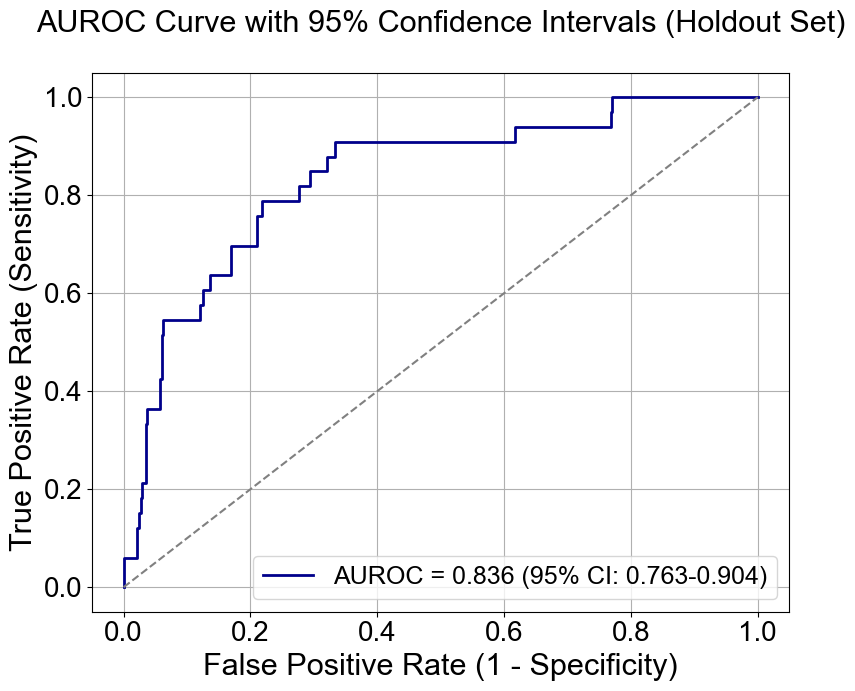

In [40]:
# Plot AUROC with confidence intervals
plot_roc_with_ci(best_final_model, X_holdout_preprocessed, y_holdout)

## Calculate permutation importance on the training set using best_final_model based on finding optimal threshold

In [41]:
# Perform permutation importance on training set
from sklearn.inspection import permutation_importance


dataset_name = "Baseline + ExWAS \n(Physician-diagnosed asthma at 5 years of age)"

dataset_scoring_metrics[dataset_name] = {}

if 1:
    perm_importance = permutation_importance(
        best_final_model,
        X_train_preprocessed,
        y_train,
        n_repeats=100,
        random_state=42,
        n_jobs=-1,
        scoring="neg_log_loss"
    )

    # Store in DataFrame
    feature_importances_df = pd.DataFrame({
        'Feature': features,
        'Importance Mean': perm_importance.importances_mean,
        'Importance Std': perm_importance.importances_std
    }).sort_values(by='Importance Mean', ascending=False)

    feature_importances_df = feature_importances_df[feature_importances_df['Importance Mean'] > 0]

    # Print top features
    print(f"\nTop permutation importances for {best_final_model} (Training set):")
    print(feature_importances_df)



Top permutation importances for HistGradientBoostingClassifier(class_weight='balanced', learning_rate=0.05,
                               max_depth=10, max_iter=75, random_state=43) (Training set):
                                               Feature  Importance Mean  \
75                           log_dehp_in_house_dust_3m         0.076161   
79                               family_asthma_history         0.034474   
2                                    Weight_for_age_0m         0.010074   
102                              PM25_PM_9m_post_birth         0.009831   
99                                PM25_PM_3m_pre_birth         0.008032   
126                           AQSMK_PM25_3m_post_birth         0.005757   
72                    num_systemic_antibotics_birth_1y         0.005328   
128                           AQSMK_PM25_9m_post_birth         0.004816   
120                                 O3_8H_3m_pre_birth         0.004731   
30                                   Weight_for_ag

## Select for features that account for 90% of total importance

In [16]:
import pandas as pd

# Suppose your DataFrame is called perm_importance_df
# and has a column 'importance' with mean permutation importances.

# 1. Sort by importance (descending)
df_sorted = feature_importances_df.sort_values('Importance Mean', ascending=False).reset_index(drop=True)

# 2. Compute cumulative sum and cumulative proportion
df_sorted['cumulative_importance'] = df_sorted['Importance Mean'].cumsum()
df_sorted['cumulative_percent'] = 100 * df_sorted['cumulative_importance'] / df_sorted['Importance Mean'].sum()

# 3. Find the cutoff row where cumulative percent reaches 90%
cutoff_index = df_sorted[df_sorted['cumulative_percent'] <= 90].index[-1]
cutoff_value = df_sorted.loc[cutoff_index, 'Importance Mean']

# 4. Filter top features contributing to 90% of total importance
feature_importances_df = df_sorted[df_sorted['cumulative_percent'] <= 90]

In [17]:
feature_importances_df

,Feature,Importance Mean,Importance Std,cumulative_importance,cumulative_percent
0,log_dehp_in_house_dust_3m,0.076161,0.005444,0.076161,31.962117
1,family_asthma_history,0.034474,0.004037,0.110635,46.429401
2,Weight_for_age_0m,0.010074,0.001588,0.120709,50.657184
3,PM25_PM_9m_post_birth,0.009831,0.001723,0.130540,54.782827
4,PM25_PM_3m_pre_birth,0.008032,0.001252,0.138572,58.153418
5,AQSMK_PM25_3m_post_birth,0.005757,0.001099,0.144329,60.569420
6,num_systemic_antibotics_birth_1y,0.005328,0.000856,0.149657,62.805502
7,AQSMK_PM25_9m_post_birth,0.004816,0.001010,0.154474,64.826805
8,O3_8H_3m_pre_birth,0.004731,0.000750,0.159205,66.812385
9,Weight_for_age_3m,0.004223,0.000791,0.163428,68.584810


In [116]:
feature_importances_df.to_csv("output/feature_importances_asthma_5y_baseline_exwas_hgb.csv", index=False)

## Calculate permutation importance on the validation set using best_final_model using optimal threshold

In [18]:


if 1:
    perm_importance = permutation_importance(
        best_final_model,
        X_holdout_preprocessed,
        y_holdout,
        n_repeats=100,
        random_state=42,
        n_jobs=-1,
        scoring="neg_log_loss"
    )

    # Store results in a DataFrame
    feature_importances_validation_set_df = pd.DataFrame({
        'Feature': features,
        'Importance Mean': perm_importance.importances_mean,
        'Importance Std': perm_importance.importances_std
    }).sort_values(by='Importance Mean', ascending=False)

    feature_importances_validation_set_df = feature_importances_validation_set_df[feature_importances_validation_set_df['Importance Mean'] > 0]

    # Print top 20 features
    print(f"\nTop 20 permutation importances for {best_final_model} (Validation set):")
    print(feature_importances_validation_set_df)


Top 20 permutation importances for HistGradientBoostingClassifier(class_weight='balanced', learning_rate=0.05,
                               max_depth=10, max_iter=75, random_state=43) (Validation set):
                                               Feature  Importance Mean  \
75                           log_dehp_in_house_dust_3m         0.054476   
79                               family_asthma_history         0.014071   
98                                PM25_PM_6m_pre_birth         0.003147   
124                            AQSMK_PM25_6m_pre_birth         0.003037   
0                                  Anesthetic_delivery         0.002484   
84   frequency_of_use_of_chemical_hand_cleaner_pren...         0.002119   
27                                   FAllergies_Mother         0.001856   
95                                NO2_LUR_9m_pre_birth         0.001683   
115               child_fed_eggs_nuts_peanuts_before2y         0.001629   
39                                 BF_Implied

In [19]:
# Suppose your DataFrame is called perm_importance_df
# and has a column 'importance' with mean permutation importances.

# 1. Sort by importance (descending)
df_sorted = feature_importances_validation_set_df.sort_values('Importance Mean', ascending=False).reset_index(drop=True)

# 2. Compute cumulative sum and cumulative proportion
df_sorted['cumulative_importance'] = df_sorted['Importance Mean'].cumsum()
df_sorted['cumulative_percent'] = 100 * df_sorted['cumulative_importance'] / df_sorted['Importance Mean'].sum()

# 3. Find the cutoff row where cumulative percent reaches 95%
cutoff_index = df_sorted[df_sorted['cumulative_percent'] <= 95].index[-1]
cutoff_value = df_sorted.loc[cutoff_index, 'Importance Mean']

# 4. Filter top features contributing to 90% of total importance
feature_importances_validation_set_df = df_sorted[df_sorted['cumulative_percent'] <= 95]

In [20]:
feature_importances_validation_set_df

,Feature,Importance Mean,Importance Std,cumulative_importance,cumulative_percent
0,log_dehp_in_house_dust_3m,0.054476,0.010041,0.054476,58.169711
1,family_asthma_history,0.014071,0.007083,0.068546,73.194485
2,PM25_PM_6m_pre_birth,0.003147,0.002490,0.071694,76.555388
3,AQSMK_PM25_6m_pre_birth,0.003037,0.002108,0.074730,79.797830
4,Anesthetic_delivery,0.002484,0.002160,0.077214,82.449985
5,frequency_of_use_of_chemical_hand_cleaner_pren...,0.002119,0.001364,0.079333,84.712968
6,FAllergies_Mother,0.001856,0.000609,0.081189,86.694651
7,NO2_LUR_9m_pre_birth,0.001683,0.002544,0.082872,88.492003
8,child_fed_eggs_nuts_peanuts_before2y,0.001629,0.000814,0.084501,90.230944
9,BF_Implied_Duration,0.001566,0.001339,0.086067,91.903139


## Calculate direction of effect using logistic regression

### Method 1 - use only study site and season of birth as covariates

In [21]:
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import numpy as np
import pandas as pd


pd.set_option('future.no_silent_downcasting', True)

feature_effects_df = feature_importances_df.copy()

for index, row in feature_effects_df.iterrows():

    if 1:
        print("#####"+row['Feature'])

        tmp = df_for_logistic_regression.copy()
        tmp = tmp[~tmp[row['Feature']].isna()]
    
        tmp = tmp[~tmp[target].isna()]


        if row['Feature'] not in ['Sex_M']:
            tmp = tmp[['Sex_M',row['Feature'],target]]
        else:
            tmp = tmp[['Sex_M',target]]


        
        
    
        y=tmp[target]     
        tmp.drop(columns=[target],inplace=True)
        # Replace all False with 0 and all True with 1
        tmp.replace({False: 0, True: 1}, inplace=True)

        tmp['Sex_M'] = tmp['Sex_M'].astype(int)
      


        unique_vals = tmp[row['Feature']].unique()
        if tmp[row['Feature']].dtype == 'object' and len(unique_vals) == 2:
            tmp[row['Feature']] = tmp[row['Feature']].astype(int)

        X = sm.add_constant(tmp) # add constant to allow intercept  

        
        
       
    
        unique_vals = X[row['Feature']].unique()
       
        if len(unique_vals) > 1:
                
            try:

         
                
                model = sm.Logit(y, X).fit(disp=0) # add disp=0 to turn off verbose output

                odds_ratios = pd.DataFrame(
                                        {
                                            "Coefficient": model.params,
                                            "Lower CI": model.conf_int()[0],
                                            "Upper CI": model.conf_int()[1]
                                        }
                                    )
                odds_ratios = np.exp(odds_ratios)

                odds_ratios['P-value'] = round(model.pvalues,4)
                odds_ratios = odds_ratios.loc[row['Feature']]  

                coefficient = odds_ratios['Coefficient']
                pvalue = odds_ratios['P-value']

                feature_effects_df.loc[index,"Coefficient"]=coefficient
                feature_effects_df.loc[index,"P-value"]=pvalue
            except Exception as e:
                print(f"Error fitting model for feature {row['Feature']}: {e}")
                feature_effects_df.loc[index,"Coefficient"]=np.nan
                feature_effects_df.loc[index,"P-value"]=np.nan


# Determine the direction of the effect

for index, row in feature_effects_df.iterrows():
    if row['Coefficient'] < 1 and row['P-value'] < 0.05:
        feature_effects_df.at[index, 'Effect'] = 'Decrease'
    elif row['Coefficient'] > 1 and row['P-value'] < 0.05:
        feature_effects_df.at[index, 'Effect'] = 'Increase'
    else:
        feature_effects_df.at[index, 'Effect'] = 'No Effect'
# Sort by importance
feature_effects_df = feature_effects_df[feature_effects_df['Importance Mean'].notna()]

feature_effects_df.sort_values(by='Importance Mean', ascending=False, inplace=True)


#####log_dehp_in_house_dust_3m
#####family_asthma_history
#####Weight_for_age_0m
#####PM25_PM_9m_post_birth
#####PM25_PM_3m_pre_birth
#####AQSMK_PM25_3m_post_birth
#####num_systemic_antibotics_birth_1y
#####AQSMK_PM25_9m_post_birth
#####O3_8H_3m_pre_birth
#####Weight_for_age_3m
#####PM25_PM_6m_pre_birth
#####AD_Father
#####NO2_LUR_9m_pre_birth
#####Weight_for_age_12m
#####AQSMK_PM25_6m_pre_birth
#####O3_8H_6m_pre_birth
#####BF_Implied_Duration
#####O3_8H_9m_pre_birth
#####O3_8H_3m_post_birth
#####monthly_furniture_floor_dusting_polish_use_prenatal
#####frequency_of_use_of_chemical_hand_cleaner_prenatal
#####NO2_LUR_6m_pre_birth
#####AQSMK_PM25_3m_pre_birth
#####UV_SEA_7m_post_birth
#####NO2_LUR_3m_post_birth
#####DTR_distance_to_secondary_highways_18WK
#####child_fed_eggs_nuts_peanuts_before2y
#####frequency_of_use_of_hand_sanitizer_prenatal
#####NO2_LUR_6m_post_birth


/var/folders/v5/s3gm5hxs39l26zqh0_gvfybw0000gn/T/ipykernel_63865/3731351141.py:7: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [22]:
logistic_regression_results = feature_effects_df[['Feature','Coefficient','P-value','Effect']].copy()
logistic_regression_results.rename(columns={'Coefficient':'Odds Ratio 1'}, inplace=True)
logistic_regression_results.rename(columns={'P-value':'P-value 1'}, inplace=True)
logistic_regression_results.rename(columns={'Effect':'Effect 1'}, inplace=True)
logistic_regression_results

,Feature,Odds Ratio 1,P-value 1,Effect 1
0,log_dehp_in_house_dust_3m,2.166326,0.0000,Increase
1,family_asthma_history,3.734219,0.0000,Increase
2,Weight_for_age_0m,0.981041,0.8561,No Effect
3,PM25_PM_9m_post_birth,1.130625,0.0035,Increase
4,PM25_PM_3m_pre_birth,1.014844,0.6687,No Effect
5,AQSMK_PM25_3m_post_birth,0.992727,0.9146,No Effect
6,num_systemic_antibotics_birth_1y,1.731501,0.0000,Increase
7,AQSMK_PM25_9m_post_birth,1.119342,0.0955,No Effect
8,O3_8H_3m_pre_birth,1.016057,0.1580,No Effect
9,Weight_for_age_3m,1.048142,0.6313,No Effect


### Method 2 - use all covariates used in exwas as a covariates

In [23]:
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import numpy as np
import pandas as pd


pd.set_option('future.no_silent_downcasting', True)

feature_effects_df = feature_importances_df.copy()

for index, row in feature_effects_df.iterrows():

    if 1:
        print("#####"+row['Feature'])

        tmp = df_for_logistic_regression.copy()
        tmp = tmp[~tmp[row['Feature']].isna()]
    
        tmp = tmp[~tmp[target].isna()]
        tmp = tmp.fillna(tmp.median())
        print(target)

        # covariates = ['family_asthma_history', 'num_antibiotic_courses_birth_to_1y', 'older_children_in_home_3m', 'total_household_income_PR18WK' , 'EBF_6m', 'vaginal_birth', 'prenatal_smoke_exposure', 'summer_birth', 'winter_birth', 'autumn_birth','site_toronto', 'site_vancouver', 'site_edmonton','is_male','is_caucasian']

        if row['Feature'] not in ['Sex_M','BF_Status_6m_Exclusive','Child_Ethnicity_Caucasian','Mode_of_delivery_Vaginal','Study_Center_Edmonton','Study_Center_Winnipeg','Study_Center_Vancouver', 'total_household_income_PR18WK','years_education_mother_PR18WK','family_asthma_history','num_systemic_antibotics_birth_1y','summer_birth', 'winter_birth', 'autumn_birth']:
            tmp = tmp[['Sex_M','BF_Status_6m_Exclusive','Child_Ethnicity_Caucasian','Mode_of_delivery_Vaginal','Study_Center_Edmonton','Study_Center_Winnipeg','Study_Center_Vancouver', 'total_household_income_PR18WK','years_education_mother_PR18WK','family_asthma_history','num_systemic_antibotics_birth_1y','summer_birth', 'winter_birth', 'autumn_birth',row['Feature'],target]]
        else:
            tmp = tmp[['Sex_M','BF_Status_6m_Exclusive','Child_Ethnicity_Caucasian','Mode_of_delivery_Vaginal','Study_Center_Edmonton','Study_Center_Winnipeg','Study_Center_Vancouver', 'total_household_income_PR18WK','years_education_mother_PR18WK','family_asthma_history','num_systemic_antibotics_birth_1y','summer_birth', 'winter_birth', 'autumn_birth',target]]


        
        
    
        y=tmp[target]     
        tmp.drop(columns=[target],inplace=True)
        # Replace all False with 0 and all True with 1
        tmp.replace({False: 0, True: 1}, inplace=True)

        tmp['Sex_M'] = tmp['Sex_M'].astype(int)
        tmp['BF_Status_6m_Exclusive'] = tmp['BF_Status_6m_Exclusive'].astype(int)
        tmp['Child_Ethnicity_Caucasian'] = tmp['Child_Ethnicity_Caucasian'].astype(int)
        tmp['Mode_of_delivery_Vaginal'] = tmp['Mode_of_delivery_Vaginal'].astype(int)
        tmp['Study_Center_Edmonton'] = tmp['Study_Center_Edmonton'].astype(int)
        tmp['Study_Center_Winnipeg'] = tmp['Study_Center_Winnipeg'].astype(int)
        tmp['Study_Center_Vancouver'] = tmp['Study_Center_Vancouver'].astype(int)


        unique_vals = tmp[row['Feature']].unique()
        if tmp[row['Feature']].dtype == 'object' and len(unique_vals) == 2:
            tmp[row['Feature']] = tmp[row['Feature']].astype(int)

        X = sm.add_constant(tmp) # add constant to allow intercept  

        
              
    
        unique_vals = X[row['Feature']].unique()
       
        if len(unique_vals) > 1:
                
            try:

                
                
                model = sm.Logit(y, X).fit(disp=0) # add disp=0 to turn off verbose output

                odds_ratios = pd.DataFrame(
                                        {
                                            "Coefficient": model.params,
                                            "Lower CI": model.conf_int()[0],
                                            "Upper CI": model.conf_int()[1]
                                        }
                                    )
                odds_ratios = np.exp(odds_ratios)

                odds_ratios['P-value'] = round(model.pvalues,4)
                odds_ratios = odds_ratios.loc[row['Feature']]  

                coefficient = odds_ratios['Coefficient']
                pvalue = odds_ratios['P-value']

                feature_effects_df.loc[index,"Coefficient"]=coefficient
                feature_effects_df.loc[index,"P-value"]=pvalue
            except Exception as e:
                print(f"Error fitting model for feature {row['Feature']}: {e}")
            #    feature_effects_df.loc[index,"Coefficient"]=np.nan
            #    feature_effects_df.loc[index,"P-value"]=np.nan


# Determine the direction of the effect

for index, row in feature_effects_df.iterrows():
    if row['Coefficient'] < 1 and row['P-value'] < 0.05:
        feature_effects_df.at[index, 'Effect'] = 'Decrease'
    elif row['Coefficient'] > 1 and row['P-value'] < 0.05:
        feature_effects_df.at[index, 'Effect'] = 'Increase'
    else:
        feature_effects_df.at[index, 'Effect'] = 'No Effect'
# Sort by importance
feature_effects_df = feature_effects_df[feature_effects_df['Importance Mean'].notna()]

feature_effects_df.sort_values(by='Importance Mean', ascending=False, inplace=True)


/var/folders/v5/s3gm5hxs39l26zqh0_gvfybw0000gn/T/ipykernel_63865/484365015.py:7: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


#####log_dehp_in_house_dust_3m
definite_asthma_5y
#####family_asthma_history
definite_asthma_5y
#####Weight_for_age_0m
definite_asthma_5y
#####PM25_PM_9m_post_birth
definite_asthma_5y
#####PM25_PM_3m_pre_birth
definite_asthma_5y
#####AQSMK_PM25_3m_post_birth
definite_asthma_5y
#####num_systemic_antibotics_birth_1y
definite_asthma_5y
#####AQSMK_PM25_9m_post_birth
definite_asthma_5y
#####O3_8H_3m_pre_birth
definite_asthma_5y
#####Weight_for_age_3m
definite_asthma_5y
#####PM25_PM_6m_pre_birth
definite_asthma_5y
#####AD_Father
definite_asthma_5y
#####NO2_LUR_9m_pre_birth
definite_asthma_5y
#####Weight_for_age_12m
definite_asthma_5y
#####AQSMK_PM25_6m_pre_birth
definite_asthma_5y
#####O3_8H_6m_pre_birth
definite_asthma_5y
#####BF_Implied_Duration
definite_asthma_5y
#####O3_8H_9m_pre_birth
definite_asthma_5y
#####O3_8H_3m_post_birth
definite_asthma_5y
#####monthly_furniture_floor_dusting_polish_use_prenatal
definite_asthma_5y
#####frequency_of_use_of_chemical_hand_cleaner_prenatal
definite_a

/Users/glwinsor/miniconda3/envs/ml-workshop/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/glwinsor/miniconda3/envs/ml-workshop/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


In [24]:
logistic_regression_results2 = feature_effects_df[['Feature','Coefficient','P-value','Effect']].copy()
logistic_regression_results2.rename(columns={'Coefficient':'Odds Ratio 2'}, inplace=True)
logistic_regression_results2.rename(columns={'P-value':'P-value 2'}, inplace=True)
logistic_regression_results2.rename(columns={'Effect':'Effect 2'}, inplace=True)

In [25]:
logistic_regression_results_merged_df = pd.merge(logistic_regression_results, logistic_regression_results2, how="left", on='Feature')


## Add time points and rename features for consistency (7b)

In [26]:
for index, row in feature_effects_df.iterrows():
    if row['Feature'].endswith("4y") or row['Feature'].endswith("4Y") or row['Feature'].endswith("48m"):
        feature_effects_df.at[index, 'Time_Point'] = '4 Years'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_4y", "").replace("_4Y", "").replace("_48m", "")

    if row['Feature'].endswith("3y") or row['Feature'].endswith("3Y") or row['Feature'].endswith("3yCLA") or row['Feature'].endswith("36m"):
        feature_effects_df.at[index, 'Time_Point'] = '3 Years'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_3y", "").replace("_3Y", "").replace("_3yCLA", "").replace("_36m", "")
        
    if row['Feature'].endswith("1y") or row['Feature'].endswith("1Y")or row['Feature'].endswith("12m")  or "_12m_" in row['Feature'] or row['Feature'].endswith("1yCLA"):
        feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_1y", "").replace("_1Y", "").replace("_12m", "").replace("_1yCLA", "")

    if row['Feature'].endswith("2hy") or row['Feature'].endswith("30m") or row['Feature'].endswith("2yh") or row['Feature']=='BF_Implied_Duration':
        feature_effects_df.at[index, 'Time_Point'] = '2.5 Years'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_2hy", "").replace("_30m", "").replace("_2yh", "")

    if row['Feature'].endswith("2y") or row['Feature'].endswith("2Y") or row['Feature'].endswith("24m")  or "_24m_" in row['Feature']:
        feature_effects_df.at[index, 'Time_Point'] = '2 Years'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_2y", "").replace("_2y", "").replace("_24m", "") 

    if row['Feature'].endswith("3m") or row['Feature'].endswith("3M")  or "_3m_" in row['Feature']:
        feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_3m", "").replace("_3M", "") 

    if row['Feature'].endswith("_6m") or row['Feature'].endswith("_6M") or "_6m_" in row['Feature']:
        feature_effects_df.at[index, 'Time_Point'] = '6 Months'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_6m$", "").replace("_6M$", "").replace("_6m", "")

    if row['Feature'].endswith("_1m") or row['Feature'].endswith("_1M") or "_1m_" in row['Feature']:
        feature_effects_df.at[index, 'Time_Point'] = '1 Month'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_1m", "").replace("_1M", "")


    if row['Feature'].endswith("_9m") or row['Feature'].endswith("_9M") or "_9m_" in row['Feature']:
        feature_effects_df.at[index, 'Time_Point'] = '9 Months'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_9m", "").replace("_9M", "")


    if row['Feature'].endswith("_18m") or row['Feature'].endswith("_18M")  or "_18m_" in row['Feature']:
        feature_effects_df.at[index, 'Time_Point'] = '18 Months'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_18m", "").replace("_18M", "") 

    if row['Feature'].endswith("prenatal") or row['Feature'].endswith("18W") or row['Feature'].endswith("18w")  or "36week" in row['Feature']  or row['Feature'].startswith("Prenatal")  or row['Feature'].startswith("Mom") or row['Feature'].startswith("Mother")  or row['Feature'].endswith("Mother") or row['Feature'].endswith("Mom")  or "No_of_Pregnancy" in row['Feature'] or "Smoke_Prenatal_Maternal" in row['Feature']  or "Smoke_Prenatal_Secondhand" in row['Feature']:
        feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_prenatal", "").replace("_18W", "").replace("_18w$", "").replace("_18week", "").replace("_36week", "")

    if row['Feature'].endswith("_0m") or row['Feature'].endswith("_0M") or row['Feature'].endswith("birth") or row['Feature'].endswith("Birth") or "delivery" in row['Feature']  or "Apgar" in row['Feature'] or "F10" in row['Feature'] or "Gest_Days" in row['Feature']:
        feature_effects_df.at[index, 'Time_Point'] = 'Birth'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("_0m", "").replace("_0M", "").replace("_birth", "").replace("Gest_Days", "Gestational days at birth") 

    if "Study_Center" in row['Feature'] or "Ethnicity" in row['Feature'] or "Stay_Duration" in row['Feature'] or "Sex_M" in row['Feature']:
        feature_effects_df.at[index, 'Time_Point'] = 'Birth'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature']

    if row['Feature']=='took_systemic_antibiotics_7_to_12_months':
        feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("took_systemic_antibiotics_7_to_12_months", "Took_systemic_antibiotic_between_7-12_months")
    if row['Feature']=='CESD_18week_High_Depression':
        feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("CESD_18week_High_Depression", "CESD High Depression Group (18 weeks)")

    if row['Feature']=='CESD_36week_High_Depression':
        feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("CESD_36week_High_Depression", "CESD High Depression Group (36 weeks)")

    if row['Feature']=='num_systemic_antibotics_birth_1y':
        feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        feature_effects_df.loc[index, 'New_Feature'] = row['Feature'].replace("num_systemic_antibotics_birth_1y", "Number_of_systemic_antibiotics_courses_between_birth_and_1y")





for index, row in feature_effects_df.iterrows():
    if row['New_Feature']=='BF':
        feature_effects_df.loc[index, 'New_Feature'] = 'Breastfeeding - any'
    if row['New_Feature']=='Chao1_diversity_metagenomic':
        feature_effects_df.loc[index, 'New_Feature'] = 'Alpha diversity - Chao1'
    if row['New_Feature']=='shannon_diversity_metagenomic':
        feature_effects_df.loc[index, 'New_Feature'] = 'Alpha diversity - Shannon'
    if row['New_Feature']=='inverse_simpson_diversity_metagenomic':
        feature_effects_df.loc[index, 'New_Feature'] = 'Alpha diversity - Inverse Simpson'

    if row['New_Feature']=='Child_Food':
        feature_effects_df.loc[index, 'New_Feature'] = 'Skin prick positive - food allergen (child)'
    if row['New_Feature']=='Child_Inhalant':
        feature_effects_df.loc[index, 'New_Feature'] = 'Skin prick positive - aeroallergen (child)'

    if row['New_Feature']=='Child_Atopy':
        feature_effects_df.loc[index, 'New_Feature'] = 'Skin prick positive - food or aeroallergen (child)'

    if row['New_Feature']=='Cumulative_Wheeze':
        feature_effects_df.loc[index, 'New_Feature'] = 'Wheeze (cumulative number of episodes)'

    if row['New_Feature']=='Recurrent_Wheeze':
        feature_effects_df.loc[index, 'New_Feature'] = 'Wheeze (recurrent)'

    if row['New_Feature']=='Epi_Noncold_Wheeze':
        feature_effects_df.loc[index, 'New_Feature'] = 'Wheeze (without a cold) - number of episodes'
    if row['New_Feature']=='Noncold_Wheeze':
        feature_effects_df.loc[index, 'New_Feature'] = 'Wheeze (without a cold) - any episodes'
    
    if row['New_Feature']=='FAllergies_Father':
        feature_effects_df.loc[index, 'New_Feature'] = 'Food allergy (father)'
    if row['New_Feature']=='FAllergies_Mother':
        feature_effects_df.loc[index, 'New_Feature'] = 'Food allergy (mother)'
    if row['New_Feature']=='WheezeCLA':
        feature_effects_df.loc[index, 'New_Feature'] = 'Wheeze (any) based on clinical assessment'
    if row['New_Feature']=='Wheeze':
        feature_effects_df.loc[index, 'New_Feature'] = 'Wheeze (any) based on questionnaire'
    if row['New_Feature']=='eos_relative':
        feature_effects_df.loc[index, 'New_Feature'] = 'Eosinophils (relative levels)'
    if row['New_Feature']=='Systolic_BPCLA':
        feature_effects_df.loc[index, 'New_Feature'] = 'Child\'s blood pressure (systolic)'
    if row['New_Feature']=='Diastolic_BPCLA':
        feature_effects_df.loc[index, 'New_Feature'] = 'Child\'s blood pressure (diastolic)'
    if "dehp" in row['Feature']:
        feature_effects_df.loc[index, 'New_Feature'] = "DEHP phthalate in house dust"
    if row['New_Feature']=='vitamins_supplements':
        feature_effects_df.loc[index, 'New_Feature'] = "Vitamins or supplements taken"

    if row['New_Feature']=='log_eos_lymphs_ratio':
        feature_effects_df.loc[index, 'New_Feature'] = 'Eosinophil/lymphocyte ratio'
    if row['New_Feature']=='log_eos_monos_ratio':
        feature_effects_df.loc[index, 'New_Feature'] = 'Eosinophil/monocyte ratio'
    if row['New_Feature']=='log_eos_neuts_ratio':
        feature_effects_df.loc[index, 'New_Feature'] = 'Eosinophil/neutrophil ratio'
    if row['New_Feature']=='log_neuts_lymphs_ratio':
        feature_effects_df.loc[index, 'New_Feature'] = 'Neutrophil/lymphocyte ratio'
    if row['New_Feature']=='log_monos_lymphs_ratio':
        feature_effects_df.loc[index, 'New_Feature'] = 'Monocyte/lymphocyte ratio'
    if row['New_Feature']=='log_basos_lymphs_ratio':
        feature_effects_df.loc[index, 'New_Feature'] = 'Basophil/lymphocyte ratio'
    if "bronchodilator" in str(row['New_Feature']):
        feature_effects_df.loc[index, 'New_Feature'] = "Spirometry "+row['New_Feature'].replace("_"," ")
    if row['New_Feature']=='Weight_for_age':
        feature_effects_df.loc[index, 'New_Feature'] = 'Weight for age (child)'
    if row['New_Feature']=='child_fed_eggs_before':
        feature_effects_df.loc[index, 'New_Feature'] = 'Child fed eggs'
    if row['New_Feature']=='Took_systemic_antibiotic_between_7-12_months':
        feature_effects_df.loc[index, 'New_Feature'] = 'Systemic antibiotics - 1 or more courses (7-12m)'
    if row['New_Feature']=='Number_of_systemic_antibiotics_courses_between_birth_and_1y':   
        feature_effects_df.loc[index, 'New_Feature'] = 'Systemic antibiotics - Number of courses since birth'
   
    if row['New_Feature']=='RIfrequency_Later':
        feature_effects_df.loc[index, 'New_Feature'] = 'Respiratory infection frequency'
    if row['New_Feature']=='breast_milk_adrenic_acid_levels':
            feature_effects_df.loc[index, 'New_Feature'] = 'Breast milk - adrenic acid (%)'
    if row['New_Feature']=='breastmilk_dihomo_gamma_linolenic_acid_levels':
            feature_effects_df.loc[index, 'New_Feature'] = 'Breast milk - dihomo gamma linolenic acid (%)'
    if row['New_Feature']=='breastmilk_gamma_linolenic_acid_levels':
            feature_effects_df.loc[index, 'New_Feature'] = 'Breast milk - gamma linolenic acid (%)'
  

    if row['New_Feature']=='weekly_chem_hand_cleaner_use_mother':
        feature_effects_df.loc[index, 'New_Feature'] = 'Chem. hand cleaner  weekly (mother)'
    if row['New_Feature']=='RIseverity_Later':
        feature_effects_df.loc[index, 'New_Feature'] = 'Respiratory infection severity'
    if row['New_Feature']=='RIseverity_Earlier':
        feature_effects_df.loc[index, 'New_Feature'] = 'Respiratory infection severity'
    if row['New_Feature']=='No_of_Pregnancy':
        feature_effects_df.loc[index, 'New_Feature'] = 'Number of pregnancies'
    if row['New_Feature']=='definite_asthma':
        feature_effects_df.loc[index, 'New_Feature'] = 'Asthma diagnosed by physician'
    if row['New_Feature']=='Study_Center_Toronto':
        feature_effects_df.loc[index, 'New_Feature'] = 'Study center - Toronto'
    if row['New_Feature']=='Mom_Atopy':
        feature_effects_df.loc[index, 'New_Feature'] = 'Skin prick positive - food or aeroallergen (mother)'


    if row['New_Feature']=='RIfrequency_Later':
        feature_effects_df.loc[index, 'New_Feature'] = 'Respiratory infection frequency'
    if row['New_Feature']=='breast_milk_adrenic_acid_levels':
            feature_effects_df.loc[index, 'New_Feature'] = 'Breast milk - adrenic acid (%)'
    if row['New_Feature']=='breastmilk_dihomo_gamma_linolenic_acid_levels':
            feature_effects_df.loc[index, 'New_Feature'] = 'Breast milk - dihomo gamma linolenic acid (%)'
    if row['New_Feature']=='breastmilk_gamma_linolenic_acid_levels':
            feature_effects_df.loc[index, 'New_Feature'] = 'Breast milk - gamma linolenic acid (%)'
    if row['New_Feature']=='frequency_of_use_of_chemical_hand_cleaner_by_mother':
            feature_effects_df.loc[index, 'New_Feature'] = 'Chemical hand cleaner - frequency of use by mother'
    if row['New_Feature']=='Pulse_RateCLA':
            feature_effects_df.loc[index, 'New_Feature'] = 'Pulse rate (clinical assessment)'
    if row['New_Feature']=='PSS_Missing':
            feature_effects_df.loc[index, 'New_Feature'] = 'Perceived stress (mother) - no response'
    if row['New_Feature']=='PSS_Low_Stress':
            feature_effects_df.loc[index, 'New_Feature'] = 'Perceived stress (mother) - low'

   # 'anti-allergic_taken_between_7m_and', 'daily_hand_sanitizer_used', 'monthly_furniture_floor_dusting_polish_use'
    if row['New_Feature']=='daily_hand_sanitizer_used':
        feature_effects_df.loc[index, 'New_Feature'] = 'Hand sanitizer - daily use by mother'
    if row['New_Feature']=='anti-allergic_taken_between_7m_and':
        feature_effects_df.loc[index, 'New_Feature'] = 'Anti-allergic taken between 7 months and 1 year'
    if row['New_Feature']=='monthly_furniture_floor_dusting_polish_use':
        feature_effects_df.loc[index, 'New_Feature'] = 'Furniture, floor, or dusting polish - monthly or more use'
    
    # Display the updated DataFrame
feature_effects_df[['Feature', 'New_Feature', 'Time_Point','Importance Mean', 'Coefficient', 'P-value', 'Effect']]

,Feature,New_Feature,Time_Point,Importance Mean,Coefficient,P-value,Effect
0,log_dehp_in_house_dust_3m,DEHP phthalate in house dust,3 Months,0.076161,2.184788,0.0000,Increase
1,family_asthma_history,NaN,NaN,0.034474,3.829769,0.0000,Increase
2,Weight_for_age_0m,Weight for age (child),Birth,0.010074,0.996509,0.9749,No Effect
3,PM25_PM_9m_post_birth,PM25_PM_9m_post,Birth,0.009831,1.117603,0.0266,Increase
4,PM25_PM_3m_pre_birth,PM25_PM_3m_pre,Birth,0.008032,0.965090,0.4205,No Effect
5,AQSMK_PM25_3m_post_birth,AQSMK_PM25_3m_post,Birth,0.005757,0.961462,0.6240,No Effect
6,num_systemic_antibotics_birth_1y,Systemic antibiotics - Number of courses since...,1 Year,0.005328,1.730317,0.0000,Increase
7,AQSMK_PM25_9m_post_birth,AQSMK_PM25_9m_post,Birth,0.004816,1.098492,0.2291,No Effect
8,O3_8H_3m_pre_birth,O3_8H_3m_pre,Birth,0.004731,1.018261,0.3034,No Effect
9,Weight_for_age_3m,Weight for age (child),3 Months,0.004223,1.048460,0.6374,No Effect


In [27]:
import pandas as pd

# Assuming feature_effects_df is already defined
# Adjust Importance values based on Effect
feature_effects_df['Adjusted_Importance'] = feature_effects_df.apply(
    lambda row: -row['Importance Mean'] if row['Effect'] == 'Decrease' else row['Importance Mean'], axis=1
)

# Pivot the dataframe
heatmap_df = feature_effects_df.pivot_table(
    index='New_Feature',
    columns='Time_Point',
    values='Adjusted_Importance',
    aggfunc='first'  # Assuming no duplicate (New_Feature, Time_Point) pairs
).reset_index()
time_point_columns = []
for col in heatmap_df.columns:
    if col != 'New_Feature':
        # get the sum of the column
        col_sum = heatmap_df[col].sum()
        print(f"Column: {col}, Sum: {col_sum}" )
        time_point_columns.append(col)
     


# Display the resulting dataframe

#heatmap_df = heatmap_df[['New_Feature','Prenatal','Birth','3 Months','6 Months','1 Year','18 Months','2.5 Years','3 Years','4 Years','5 Years']]
#heatmap_df = heatmap_df[['New_Feature','Birth','3 Months','1 Year','3 Years','4 Years','5 Years']]
#heatmap_df = heatmap_df[['New_Feature','Prenatal','3 Months','6 Months','1 Year','3 Years','4 Years','5 Years']]
heatmap_df

Column: 1 Year, Sum: 0.008710976050389622
Column: 2 Years, Sum: -0.0018100094360016445
Column: 2.5 Years, Sum: 0.0030158633770210664
Column: 3 Months, Sum: 0.08038487635720998
Column: Birth, Sum: 0.07304207302803303
Column: Prenatal, Sum: 0.00674366065880721


Time_Point,New_Feature,1 Year,2 Years,2.5 Years,3 Months,Birth,Prenatal
0,AQSMK_PM25_3m_post,NaN,NaN,NaN,NaN,0.005757,NaN
1,AQSMK_PM25_3m_pre,NaN,NaN,NaN,NaN,0.002036,NaN
2,AQSMK_PM25_6m_pre,NaN,NaN,NaN,NaN,0.003238,NaN
3,AQSMK_PM25_9m_post,NaN,NaN,NaN,NaN,0.004816,NaN
4,BF_Implied_Duration,NaN,NaN,0.003016,NaN,NaN,NaN
5,DEHP phthalate in house dust,NaN,NaN,NaN,0.076161,NaN,NaN
6,"Furniture, floor, or dusting polish - monthly ...",NaN,NaN,NaN,NaN,NaN,0.002619
7,NO2_LUR_3m_post,NaN,NaN,NaN,NaN,0.001924,NaN
8,NO2_LUR_6m_post,NaN,NaN,NaN,NaN,0.001720,NaN
9,NO2_LUR_6m_pre,NaN,NaN,NaN,NaN,0.002202,NaN


In [28]:
# Drop rows where all Time_Point columns are NaN


heatmap_df = heatmap_df.dropna(subset=time_point_columns, how='all')

# Display the updated DataFrame
heatmap_df

Time_Point,New_Feature,1 Year,2 Years,2.5 Years,3 Months,Birth,Prenatal
0,AQSMK_PM25_3m_post,NaN,NaN,NaN,NaN,0.005757,NaN
1,AQSMK_PM25_3m_pre,NaN,NaN,NaN,NaN,0.002036,NaN
2,AQSMK_PM25_6m_pre,NaN,NaN,NaN,NaN,0.003238,NaN
3,AQSMK_PM25_9m_post,NaN,NaN,NaN,NaN,0.004816,NaN
4,BF_Implied_Duration,NaN,NaN,0.003016,NaN,NaN,NaN
5,DEHP phthalate in house dust,NaN,NaN,NaN,0.076161,NaN,NaN
6,"Furniture, floor, or dusting polish - monthly ...",NaN,NaN,NaN,NaN,NaN,0.002619
7,NO2_LUR_3m_post,NaN,NaN,NaN,NaN,0.001924,NaN
8,NO2_LUR_6m_post,NaN,NaN,NaN,NaN,0.001720,NaN
9,NO2_LUR_6m_pre,NaN,NaN,NaN,NaN,0.002202,NaN


## Single-column heatmap

/var/folders/v5/s3gm5hxs39l26zqh0_gvfybw0000gn/T/ipykernel_63865/1274606964.py:542: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color=heatmap_data['Color'].iloc[i], edgecolor='lightgrey'))


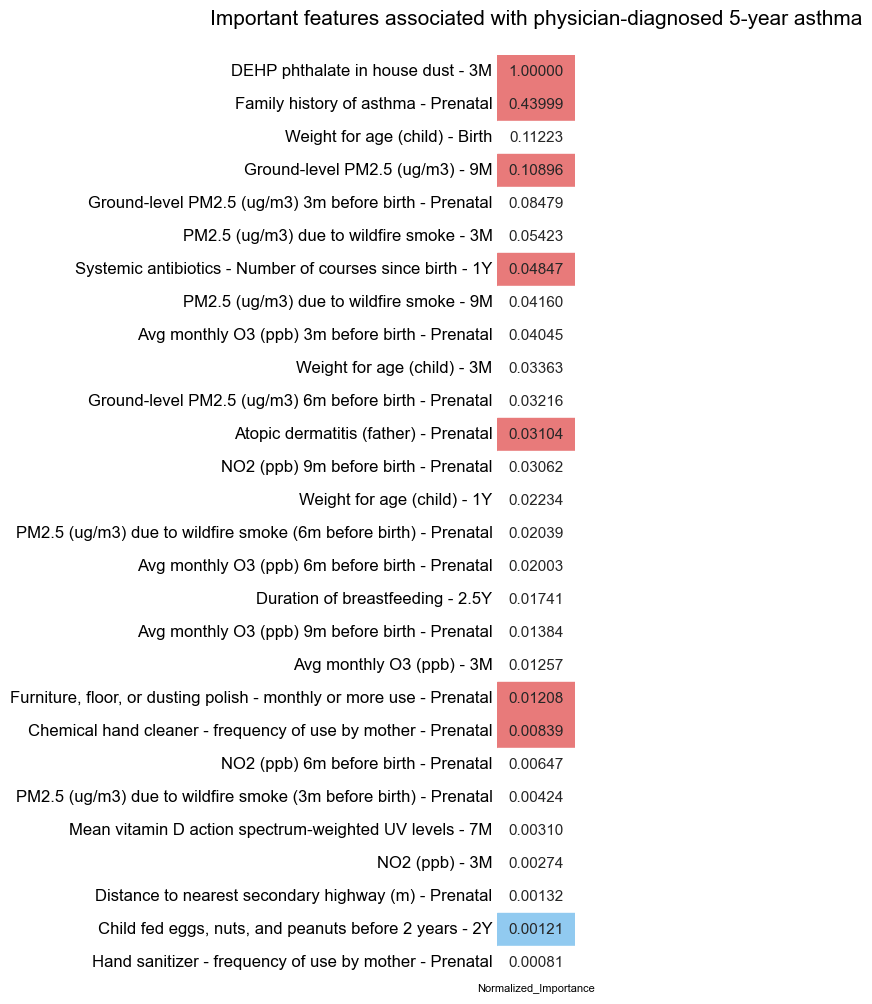

In [29]:


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Select the top features with Permutation Importance > 0
new_feature_effects_df = feature_effects_df.copy().sort_values(by="Importance Mean",ascending=False)





# Address some final features and time points that are null or need renaming
for index, row in new_feature_effects_df.iterrows():


    if row['Feature']=='O3_8H_3m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Avg monthly O3 (ppb)"

    if row['Feature']=='O3_8H_3m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Avg monthly O3 (ppb) 3m before birth"

    if row['Feature']=='O3_8H_6m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '6 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Avg monthly O3 (ppb)"

    if row['Feature']=='O3_8H_6m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Avg monthly O3 (ppb) 6m before birth"


    if row['Feature']=='O3_8H_9m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '9 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Avg monthly O3 (ppb)"

    if row['Feature']=='O3_8H_9m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Avg monthly O3 (ppb) 9m before birth"

    if row['Feature']=='AQSMK_PM25_3m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "PM2.5 (ug/m3) due to wildfire smoke"

    if row['Feature']=='AQSMK_PM25_6m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '6 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "PM2.5 (ug/m3) due to wildfire smoke"

    if row['Feature']=='AQSMK_PM25_9m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '9 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "PM2.5 (ug/m3) due to wildfire smoke"

    if row['Feature']=='AQSMK_PM25_3m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "PM2.5 (ug/m3) due to wildfire smoke (3m before birth)"

    if row['Feature']=='AQSMK_PM25_6m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "PM2.5 (ug/m3) due to wildfire smoke (6m before birth)"

    if row['Feature']=='AQSMK_PM25_9m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "PM2.5 (ug/m3) due to wildfire smoke (9m before birth)"

    if row['Feature']=='NO2_LUR_3m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "NO2 (ppb) 3m before birth"

    if row['Feature']=='NO2_LUR_6m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "NO2 (ppb) 6m before birth"

    if row['Feature']=='NO2_LUR_9m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "NO2 (ppb) 9m before birth"

    if row['Feature']=='NO2_LUR_3m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "NO2 (ppb)"

    if row['Feature']=='NO2_LUR_6m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '6 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "NO2 (ppb) 6m post birth"

    if row['Feature']=='NO2_LUR_9m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '9 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "NO2 (ppb) 9m post birth"


    if row['Feature']=='PM25_PM_3m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Ground-level PM2.5 (ug/m3) 3m before birth"

    if row['Feature']=='PM25_PM_6m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Ground-level PM2.5 (ug/m3) 6m before birth"

    if row['Feature']=='PM25_PM_9m_pre_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Ground-level PM2.5 (ug/m3) 9m before birth"

    if row['Feature']=='PM25_PM_3m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Month'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Ground-level PM2.5 (ug/m3)"

    if row['Feature']=='PM25_PM_6m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '6 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Ground-level PM2.5 (ug/m3)"

    if row['Feature']=='PM25_PM_9m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '9 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Ground-level PM2.5 (ug/m3)"


    testarray =     ['log_dehp_in_house_dust_3m',
 'family_asthma_history',
 'Weight_for_age_0m',
 'O3_8H_6m_post_birth',
 'frequency_of_use_of_chemical_hand_cleaner_prenatal',
 'PM25_PM_9m_post_birth',
 'AD_Father',
 'PM25_PM_3m_post_birth',
 'child_fed_eggs_before_2y',
 'O3_8H_3m_post_birth',
 'AQSMK_PM25_3m_post_birth',
 'AQSMK_PM25_6m_post_birth',
 'PM25_PM_3m_pre_birth',
 'Weight_for_age_3m',
 'BF_Implied_Duration',
 'Anesthetic_delivery',
 'NO2_LUR_9m_pre_birth',
 'O3_8H_3m_pre_birth',
 'Stay_Duration_Hospital',
 'took_systemic_antibiotics_7_to_12_months',
 'AQSMK_PM25_3m_pre_birth',
 'Weight_for_age_12m',
 'AQSMK_PM25_6m_pre_birth',
 'O3_8H_9m_post_birth',
 'O3_8H_6m_pre_birth',
 'AQSMK_PM25_9m_post_birth',
 'Gest_Days',
 'child_fed_eggs_nuts_peanuts_before2y',
 'NO2_LUR_6m_pre_birth',
 'DTR_distance_to_secondary_highways_18WK',
 'NO2_LUR_6m_post_birth',
 'WTH_annual_avg_length_cool_events_based_on_min_temp_18WK_above_90_percentile',
 'NO2_LUR_3m_pre_birth',
 'PSS_24m_Low_Stress',
 'PM25_PM_6m_pre_birth',
 'NO2_LUR_3m_post_birth',
 'num_systemic_antibotics_birth_1y',
 'PSS_12m_Low_Stress',
 'O3_8H_9m_pre_birth',
 'UV_SEA_7m_post_birth',
 'BF_Status_6m_Partial']

    if row['Feature']=='Father_Caucasian':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Father ethnicity caucasian"   

    if row['Feature']=='Child_Ethnicity_Caucasian':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Birth'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Child ethnicity caucasian"   

    if row['Feature']=='Child_Ethnicity_HalfCaucas':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Birth'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Child ethnicity half caucasian"   

    if row['Feature']=='F10min_No_Measure_Needed':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Birth'
        new_feature_effects_df.loc[index, 'New_Feature'] = "First 10 minutes of birth - No measures needed"   

    if row['Feature']=='Mother_Caucasian':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mother ethnicity caucasian"   
    if row['Feature']=='BF_Implied_Duration':
        new_feature_effects_df.at[index, 'Time_Point'] = '2.5 Years'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Duration of breastfeeding"   

    if row['Feature']=='PSS_18week_Low_Stress':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal, 18 Weeks'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Perceived stress (mother) - low"

    if row['Feature']=='Hayfever_Mother':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Hay fever (mother)"

    if row['Feature']=='Hayfever_Father':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Hay fever (father)"
    if row['Feature']=='prenatal_acetaminophen':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mother took acetaminophen during pregnancy"


    if row['Feature']=='prenatal_antibacterial':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mother took antibiotic during pregnancy"

    if row['Feature']=='UV_SEA_9m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '9 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mean vitamin D action spectrum-weighted UV levels"

    if row['Feature']=='UV_SEA_7m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '7 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mean vitamin D action spectrum-weighted UV levels"



        
    if row['Feature']=='UV_SEA_3m_post_birth':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mean vitamin D action spectrum-weighted UV levels"
    if row['Feature']=='log_LSTc_pct_3m':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Breast milk - Sialyl-lacto-N-tetraose c (LstC) (%)"
    

    if row['Feature']=='Prenatal_Mother_Condition':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mother had medical condition during pregnancy"

    if row['Feature']=='RIfrequency_Later':
        new_feature_effects_df.loc[index, 'New_Feature'] = 'Respiratory infection frequency'
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Years'
    if row['Feature']=='RIfrequency_Earlier':
        new_feature_effects_df.loc[index, 'New_Feature'] = 'Respiratory infection frequency'
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'

    if row['Feature']=='peanuts_or_peanutbutter_before2y':
        new_feature_effects_df.loc[index, 'New_Feature'] = 'Child fed peanuts or peanut butter'
        new_feature_effects_df.at[index, 'Time_Point'] = '2 Years'

    if row['Feature']=='food_solid_shellfish_2Y':
        new_feature_effects_df.loc[index, 'New_Feature'] = 'Child fed shellfish'
        new_feature_effects_df.at[index, 'Time_Point'] = '2 Years'
    
    if row['Feature']=='DTR_distance_to_secondary_highways_18WK':
        new_feature_effects_df.loc[index, 'New_Feature'] = 'Distance to nearest secondary highway (m)'
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        
    if row['Feature']=='FAllergies_Father':
        new_feature_effects_df.loc[index, 'New_Feature'] = 'Food allergy (father)'
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'

    if row['Feature']=='total_household_income_PR18WK':
        new_feature_effects_df.loc[index, 'New_Feature'] = 'Total household income'
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
    if row['Feature']== 'definite_asthma_5y':
        new_feature_effects_df.at[index, 'Time_Point'] = '5 Years'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Asthma diagnosed by physician"

    if row['Feature']=='Bifidobacterium_longum_present_1y':
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Bifidobacterium longum present in gut microbiome"

    if row['Feature']=='Bifidobacterium_longum_present_3m':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Bifidobacterium longum present in gut microbiome"

    if row['Feature']=='Veillonella_present_3m':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Veillonella present in gut microbiome"

    if row['Feature']=='Bifidobacterium_present_1y':
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Bifidobacterium present in gut microbiome"

    if row['Feature']=='Faecalibacterium_present_1y':
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Faecalibacterium present in gut microbiome"

    if row['Feature']=='Roseburia_present_1y':
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Roseburia present in gut microbiome"
    if row['Feature']=='Ruminococcus_present_1y':
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Ruminococcus present in gut microbiome"

        
    if row['Feature']=='Pollentress_Mother':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Pollen/tree allergy (mother)"
    if row['Feature']=='years_education_mother_PR18WK':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Years of education (mother)"
    if row['Feature']=='BF_Status_6m_Exclusive':
        new_feature_effects_df.at[index, 'Time_Point'] = '6 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Exclusive breastfeeding"

    if row['Feature']=='CESD_24m_High_Depression':
        new_feature_effects_df.at[index, 'Time_Point'] = '2 Years'
        new_feature_effects_df.loc[index, 'New_Feature'] = "CESD High Depression group"
    if row['Feature']=='Child_Ethnicity_NonCaucas':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Birth'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Child ethnicity non-Caucasian"
    if row['Feature']=='PSS_18m_Moderate_Stress':
        new_feature_effects_df.at[index, 'Time_Point'] = '18 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Perceived stress (mother) - moderate"

    if row['Feature']=='PSS_36week_Moderate_Stress':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Perceived stress (mother) - moderate"

    if row['Feature']=='PSS_18week_High_Stress':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal, 18 Weeks'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Perceived stress (mother) - high"

    if row['Feature']=='Prenatal_Gestational_Diabetes':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mother had gestational diabetes"

    if row['Feature']=='Home_Presence_Smoke_6m':
        new_feature_effects_df.at[index, 'Time_Point'] = '6 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Tobacco smoke present in home"

    if row['Feature']=='mother_pre_bronchodilator_FEF25_75_L_sec_1Y':   
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Spirometry - mother FEF25-75 (pre-bronchodilator)"

    if row['Feature']=='Sex_M':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Birth'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Biological sex is male"
    if row['Feature']=='Rothia_present_3m':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Rothia present in gut microbiome"
    if row['Feature']=='frequency_of_use_of_oven_cleaner_3m':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Oven cleaner - frequency of use by mother"
    if row['Feature']=='cookies_brownies_5Y':
        new_feature_effects_df.at[index, 'Time_Point'] = '5 Years'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Cookies or brownies consumed in last 12 months"
    if row['Feature']=='peanut_butter_5Y':
        new_feature_effects_df.at[index, 'Time_Point'] = '5 Years'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Peanut butter consumed in last 12 months"
    if row['Feature']=='AD_Father':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Atopic dermatitis (father)"

    if row['Feature']=='vitamin_D_taken_by_infant_3m':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Vitamin D taken by infant"
    
    if row['Feature']=='AD_Mother':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Atopic dermatitis (mother)" 


    if row['Feature']=='WTH_annual_avg_length_cool_events_based_on_min_temp_18WK_above_90_percentile':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Annual avg length of cool events > 90th pctl"
    if row['Feature']=='combined_monthly_disinfectant_handcleaner_and_sanitizer':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Monthly or more disinfectant use, chemical hand cleaner, and hand sanitizer"
    if row['Feature']=='frequency_of_floor_polish_use_by_mother_prenatal':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Floor polish - frequency of use by mother"
    if row['Feature']=='Mode_of_delivery_Missing':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Birth'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mode of delivery - No response"
    if row['Feature']=='PSS_36week_Moderate_Stress':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal, 36 Weeks'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Perceived stress (mother) - moderate"

    if row['Feature']=='PSS_24m_Moderate_Stress':
        new_feature_effects_df.at[index, 'Time_Point'] = '2 Years'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Perceived stress (mother) - moderate"
    if row['Feature']=='Prenatal_Nausea':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mother had nausea during pregnancy"
    if row['Feature']=='Stay_Duration_Hospital':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Birth'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Stay duration in hospital after birth"
    if row['Feature']=='BF_Status_6m_Zero':
        new_feature_effects_df.at[index, 'Time_Point'] = '6 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "No breastfeeding at 6 months"
    if row['Feature']=='frequent_baby_lotion_used_3m':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Baby lotion used more than 6 times per week"
    
    if row['Feature']=='poly_vi_sol_multivitamin_use_between_24m_and_30m':  
        new_feature_effects_df.at[index, 'Time_Point'] = '2.5 Years'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Poly-Vi-Sol multivitamin use between 24-30 months"  
    if row['Feature']=='Apgar_Score_1min':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Birth'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Apgar score at 1 minute"
    if row['Feature']=='weekly_oven_cleaner_use_mother_prenatal':   
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Oven cleaner - weekly or more use by mother"
    if row['Feature']=='Father_Asthma':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Father has asthma"
    if row['Feature']=='Smoke_Prenatal_Maternal':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mother smoked during pregnancy"
    if row['Feature']=='PSS_18week_Moderate_Stress':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal, 18 Weeks'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Perceived stress (mother) - moderate"
    if row['Feature']=='albuterol_taken_between_7m_and_1y':
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Albuterol taken in last six months"

    if row['Feature']=='father_pre_bronchodilator_FEV1_perc_predicted_1Y':
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Spirometry - father FEV1 %pred (pre-bronchodilator)"

    if row['Feature']=='Bifidobacterium_breve_present_3m':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Bifidobacterium breve present in gut microbiome"

    if row['Feature']=='Clostridium_inonocuum_present_3m':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Clostridium inonocuum present in gut microbiome"
    if row['Feature']=='Pollentress_Father':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Father has pollen/tree allergy"

    if row['Feature']=='mother_pre_bronchodilator_FEF25_75_L_sec_1Y':
        feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        feature_effects_df.loc[index, 'New_Feature'] = "Spirometry - mother FEF25-75 (pre-bronchodilator)"
    if row['Feature']=='father_pre_bronchodilator_FEF25_75_L_sec_1Y':
        feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        feature_effects_df.loc[index, 'New_Feature'] = "Spirometry - father FEF25-75 (pre-bronchodilator)"   
    if row['Feature']=='Wheeze_Father':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Father has wheeze"
    if row['Feature']=='Mother_Asthma':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Mother has asthma"
    if row['Feature']=='family_asthma_history':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Family history of asthma"
    if row['Feature']=='frequency_of_use_of_chemical_hand_cleaner_prenatal':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Chemical hand cleaner - frequency of use by mother"

    if row['Feature']=='NAE_CTRAN_3Y':
        new_feature_effects_df.at[index, 'Time_Point'] = '3 Years'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Competitive accessibility to jobs by transit"
    if row['Feature']=='BF_Status_6m_Partial':  
        new_feature_effects_df.at[index, 'Time_Point'] = '6 Months'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Partial breastfeeding"
    if row['Feature']=='num_systemic_antibotics_birth_1y':
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Systemic antibiotics - Number of courses since birth"
    if row['Feature']=='Anesthetic_delivery':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Birth'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Anesthetic used during delivery"
    if row['Feature']=='O3_annual_avg_highest_rolling_8h_avg_18WK':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "O3 annual average of highest rolling 8-hour average (ppb)"
    if row['Feature']=='ALE_index_18WK':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Active Living Environments index"
    if row['Feature']=='AQSMK_PM25_annual_smoke_exposure_18WK':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "PM2.5 annual average from wildfire smoke exposure"
    if row['Feature']=='AQSMK_PM25_annual_smoke_exposure_1Y':
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        new_feature_effects_df.loc[index, 'New_Feature'] = "PM2.5 annual average from wildfire smoke exposure"
    if row['Feature']=='frequency_of_use_of_hand_sanitizer_prenatal':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Hand sanitizer - frequency of use by mother"    
    if row['Feature']=='frequency_of_use_of_oven_cleaner_prenatal':
        new_feature_effects_df.at[index, 'Time_Point'] = 'Prenatal'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Oven cleaner - frequency of use by mother"
    if row['Feature']=='num_antibiotic_courses_birth_to_1y':
        new_feature_effects_df.at[index, 'Time_Point'] = '1 Year'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Antibiotics - Number of courses between birth and 1 year"
    if row['Feature']=='child_fed_eggs_nuts_peanuts_before2y - 2Y':
        new_feature_effects_df.at[index, 'Time_Point'] = '2 Years'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Child fed eggs, nuts, or peanuts before 2 years"
    if row['Feature']=='child_fed_peanuts_peanut_butter_before2y':
        new_feature_effects_df.at[index, 'Time_Point'] = '2 Years'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Child fed peanuts or peanut butter before 2 years"
    if row['Feature']=='child_fed_eggs_nuts_peanuts_before2y':
        new_feature_effects_df.at[index, 'Time_Point'] = '2 Years'
        new_feature_effects_df.loc[index, 'New_Feature'] = "Child fed eggs, nuts, and peanuts before 2 years"    



scaler = MinMaxScaler()
new_feature_effects_df['Normalized_Importance'] = scaler.fit_transform(new_feature_effects_df[['Importance Mean']])

# Create a custom colormap
def custom_colormap(effect, normalized_importance):
    if effect == 'Decrease':
        return "#91caf0"  # Blue for Decrease
        return plt.cm.Blues(normalized_importance)
    elif effect == 'Increase':
        return "#e87a7a"  # Red for Increase
        return plt.cm.Reds(normalized_importance)
    
    else:
        # Very light grey for any other case
        #return  (0.95, 0.95, 0.95, 1)  # RGBA for very light grey
        return (1, 1, 1, 1)  # White for any other case

# Apply the custom colormap to create a color column
new_feature_effects_df['Color'] = new_feature_effects_df.apply(
    lambda row: custom_colormap(row['Effect'], row['Normalized_Importance']), axis=1
)

for index, row in new_feature_effects_df.iterrows():
    if row['Feature'] in ['mother_pre_bronchodilator_FEV1_perc_predicted_1Y','father_pre_bronchodilator_FEV1_perc_predicted_1Y']:        
        new_feature_effects_df.at[index, 'New_Feature_Concatenated'] = row['New_Feature']
    else:
        new_feature_effects_df.at[index, 'New_Feature_Concatenated'] = row['New_Feature'] + " - " + row['Time_Point'].replace(" Years","Y").replace(" Year","Y").replace(" Months","M").replace(" Month","M").strip(" -") 


new_feature_effects_df_for_naming = new_feature_effects_df.copy()
new_feature_effects_df = new_feature_effects_df[new_feature_effects_df['Normalized_Importance'] > 0.0001]

# Create a DataFrame for the heatmap
heatmap_data = new_feature_effects_df[['New_Feature_Concatenated', 'Normalized_Importance', 'Color']].set_index('New_Feature_Concatenated')

yticks = new_feature_effects_df['New_Feature_Concatenated'].tolist()

# Plot the heatmap
plt.figure(figsize=(1, 12))
ax = sns.heatmap(
    heatmap_data[['Normalized_Importance']],
    annot=True,
    fmt=".5f",
    cmap=sns.color_palette(["#ffffff", "#ffffff"], as_cmap=True),  # Use a white colormap as a base
    cbar=False,
    linewidths=0.4,
    linecolor='lightgrey',
    annot_kws={"size": 11},
    yticklabels=True
)

ax.tick_params(axis='y', length=0)  # length=0 removes the ticks

ax.tick_params(axis='x', length=0)  # length=0 removes the ticks

# Overlay the colors on the cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color=heatmap_data['Color'].iloc[i], edgecolor='lightgrey'))

# Change the font color to white if importance is greater than 0.05
for text in ax.texts:
    importance_value = float(text.get_text())
    
    #if importance_value >= 0.51:
     #   text.set_color('white')
    if importance_value < 0.0001:
        text.set_text("< 0.0001")
        

#plt.xlabel('Importance', fontsize=10)
plt.ylabel('', fontsize=9)
plt.title('Important features associated with physician-diagnosed 5-year asthma\n', fontsize=15)
plt.xticks(fontsize=8)
plt.yticks(fontsize=12)
plt.show()

In [31]:
new_feature_effects_df

,Feature,Importance Mean,Importance Std,cumulative_importance,cumulative_percent,Coefficient,P-value,Effect,Time_Point,New_Feature,Adjusted_Importance,Normalized_Importance,Color,New_Feature_Concatenated
0,log_dehp_in_house_dust_3m,0.076161,0.005444,0.076161,31.962117,2.184788,0.0000,Increase,3 Months,DEHP phthalate in house dust,0.076161,1.000000,#e87a7a,DEHP phthalate in house dust - 3M
1,family_asthma_history,0.034474,0.004037,0.110635,46.429401,3.829769,0.0000,Increase,Prenatal,Family history of asthma,0.034474,0.439991,#e87a7a,Family history of asthma - Prenatal
2,Weight_for_age_0m,0.010074,0.001588,0.120709,50.657184,0.996509,0.9749,No Effect,Birth,Weight for age (child),0.010074,0.112226,"(1, 1, 1, 1)",Weight for age (child) - Birth
3,PM25_PM_9m_post_birth,0.009831,0.001723,0.130540,54.782827,1.117603,0.0266,Increase,9 Months,Ground-level PM2.5 (ug/m3),0.009831,0.108956,#e87a7a,Ground-level PM2.5 (ug/m3) - 9M
4,PM25_PM_3m_pre_birth,0.008032,0.001252,0.138572,58.153418,0.965090,0.4205,No Effect,Prenatal,Ground-level PM2.5 (ug/m3) 3m before birth,0.008032,0.084787,"(1, 1, 1, 1)",Ground-level PM2.5 (ug/m3) 3m before birth - P...
5,AQSMK_PM25_3m_post_birth,0.005757,0.001099,0.144329,60.569420,0.961462,0.6240,No Effect,3 Months,PM2.5 (ug/m3) due to wildfire smoke,0.005757,0.054231,"(1, 1, 1, 1)",PM2.5 (ug/m3) due to wildfire smoke - 3M
6,num_systemic_antibotics_birth_1y,0.005328,0.000856,0.149657,62.805502,1.730317,0.0000,Increase,1 Year,Systemic antibiotics - Number of courses since...,0.005328,0.048471,#e87a7a,Systemic antibiotics - Number of courses since...
7,AQSMK_PM25_9m_post_birth,0.004816,0.001010,0.154474,64.826805,1.098492,0.2291,No Effect,9 Months,PM2.5 (ug/m3) due to wildfire smoke,0.004816,0.041596,"(1, 1, 1, 1)",PM2.5 (ug/m3) due to wildfire smoke - 9M
8,O3_8H_3m_pre_birth,0.004731,0.000750,0.159205,66.812385,1.018261,0.3034,No Effect,Prenatal,Avg monthly O3 (ppb) 3m before birth,0.004731,0.040453,"(1, 1, 1, 1)",Avg monthly O3 (ppb) 3m before birth - Prenatal
9,Weight_for_age_3m,0.004223,0.000791,0.163428,68.584810,1.048460,0.6374,No Effect,3 Months,Weight for age (child),0.004223,0.033630,"(1, 1, 1, 1)",Weight for age (child) - 3M


In [32]:
feature_to_description = {}
for index, row in new_feature_effects_df.iterrows():
    feature_to_description[row['Feature']] = row['New_Feature_Concatenated'].replace("Family history of asthma - Prenatal","Family history of asthma").replace("Atopic dermatitis (father) - Prenatal","Atopic dermatitis (father)").replace("Gestational days at birth - Birth","Gestational days at birth").replace("Anesthetic used during delivery - Birth","Anesthetic used during delivery").replace("Stay duration in hospital after birth - Birth","Stay duration in hospital after birth").replace("NO2_LUR_3m_pre_birth","NO2 (ppb) 3m before birth").replace("NO2_LUR_6m_pre_birth","NO2 (ppb) 6m before birth").replace("NO2_LUR_9m_pre_birth","NO2 (ppb) 9m before birth").replace("PM25_PM_3m_pre_birth","PM2.5 - Ground-level fine particulate matter (ug/m3) 3m before birth").replace("PM25_PM_6m_pre_birth","PM2.5 - Ground-level fine particulate matter (ug/m3) 6m before birth").replace("PM25_PM_9m_pre_birth","PM2.5 - Ground-level fine particulate matter (ug/m3) 9m before birth")

In [33]:
feature_to_description['NO2_LUR_3m_pre_birth']="NO2 (ppb) 3m before birth - Prenatal"


In [34]:
feature_effects_df

,Feature,Importance Mean,Importance Std,cumulative_importance,cumulative_percent,Coefficient,P-value,Effect,Time_Point,New_Feature,Adjusted_Importance
0,log_dehp_in_house_dust_3m,0.076161,0.005444,0.076161,31.962117,2.184788,0.0000,Increase,3 Months,DEHP phthalate in house dust,0.076161
1,family_asthma_history,0.034474,0.004037,0.110635,46.429401,3.829769,0.0000,Increase,NaN,NaN,0.034474
2,Weight_for_age_0m,0.010074,0.001588,0.120709,50.657184,0.996509,0.9749,No Effect,Birth,Weight for age (child),0.010074
3,PM25_PM_9m_post_birth,0.009831,0.001723,0.130540,54.782827,1.117603,0.0266,Increase,Birth,PM25_PM_9m_post,0.009831
4,PM25_PM_3m_pre_birth,0.008032,0.001252,0.138572,58.153418,0.965090,0.4205,No Effect,Birth,PM25_PM_3m_pre,0.008032
5,AQSMK_PM25_3m_post_birth,0.005757,0.001099,0.144329,60.569420,0.961462,0.6240,No Effect,Birth,AQSMK_PM25_3m_post,0.005757
6,num_systemic_antibotics_birth_1y,0.005328,0.000856,0.149657,62.805502,1.730317,0.0000,Increase,1 Year,Systemic antibiotics - Number of courses since...,0.005328
7,AQSMK_PM25_9m_post_birth,0.004816,0.001010,0.154474,64.826805,1.098492,0.2291,No Effect,Birth,AQSMK_PM25_9m_post,0.004816
8,O3_8H_3m_pre_birth,0.004731,0.000750,0.159205,66.812385,1.018261,0.3034,No Effect,Birth,O3_8H_3m_pre,0.004731
9,Weight_for_age_3m,0.004223,0.000791,0.163428,68.584810,1.048460,0.6374,No Effect,3 Months,Weight for age (child),0.004223


In [133]:
feature_to_description = {}
for index, row in new_feature_effects_df_for_naming.iterrows():
    feature_to_description[row['Feature']] = row['New_Feature_Concatenated'].replace("Family history of asthma - Prenatal","Family history of asthma").replace("Atopic dermatitis (father) - Prenatal","Atopic dermatitis (father)").replace("Gestational days at birth - Birth","Gestational days at birth").replace("Anesthetic used during delivery - Birth","Anesthetic used during delivery").replace("Stay duration in hospital after birth - Birth","Stay duration in hospital after birth").replace("AD_Father","Atopic dermatitis (father)").replace("frequency_of_use_of_hand_santizer_prenatal","Hand sanitizer - frequency of use by mother - prenatal").replace("Hayfever_Mother","Mother had hayfever").replace("DTR_distance_to_secondary_highways_18wk","Distance to nearest secondary highway (m) - Prenatal")

## Figure 5a: Beeswarm plot of SHAP values

/Users/glwinsor/miniconda3/envs/ml-workshop/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


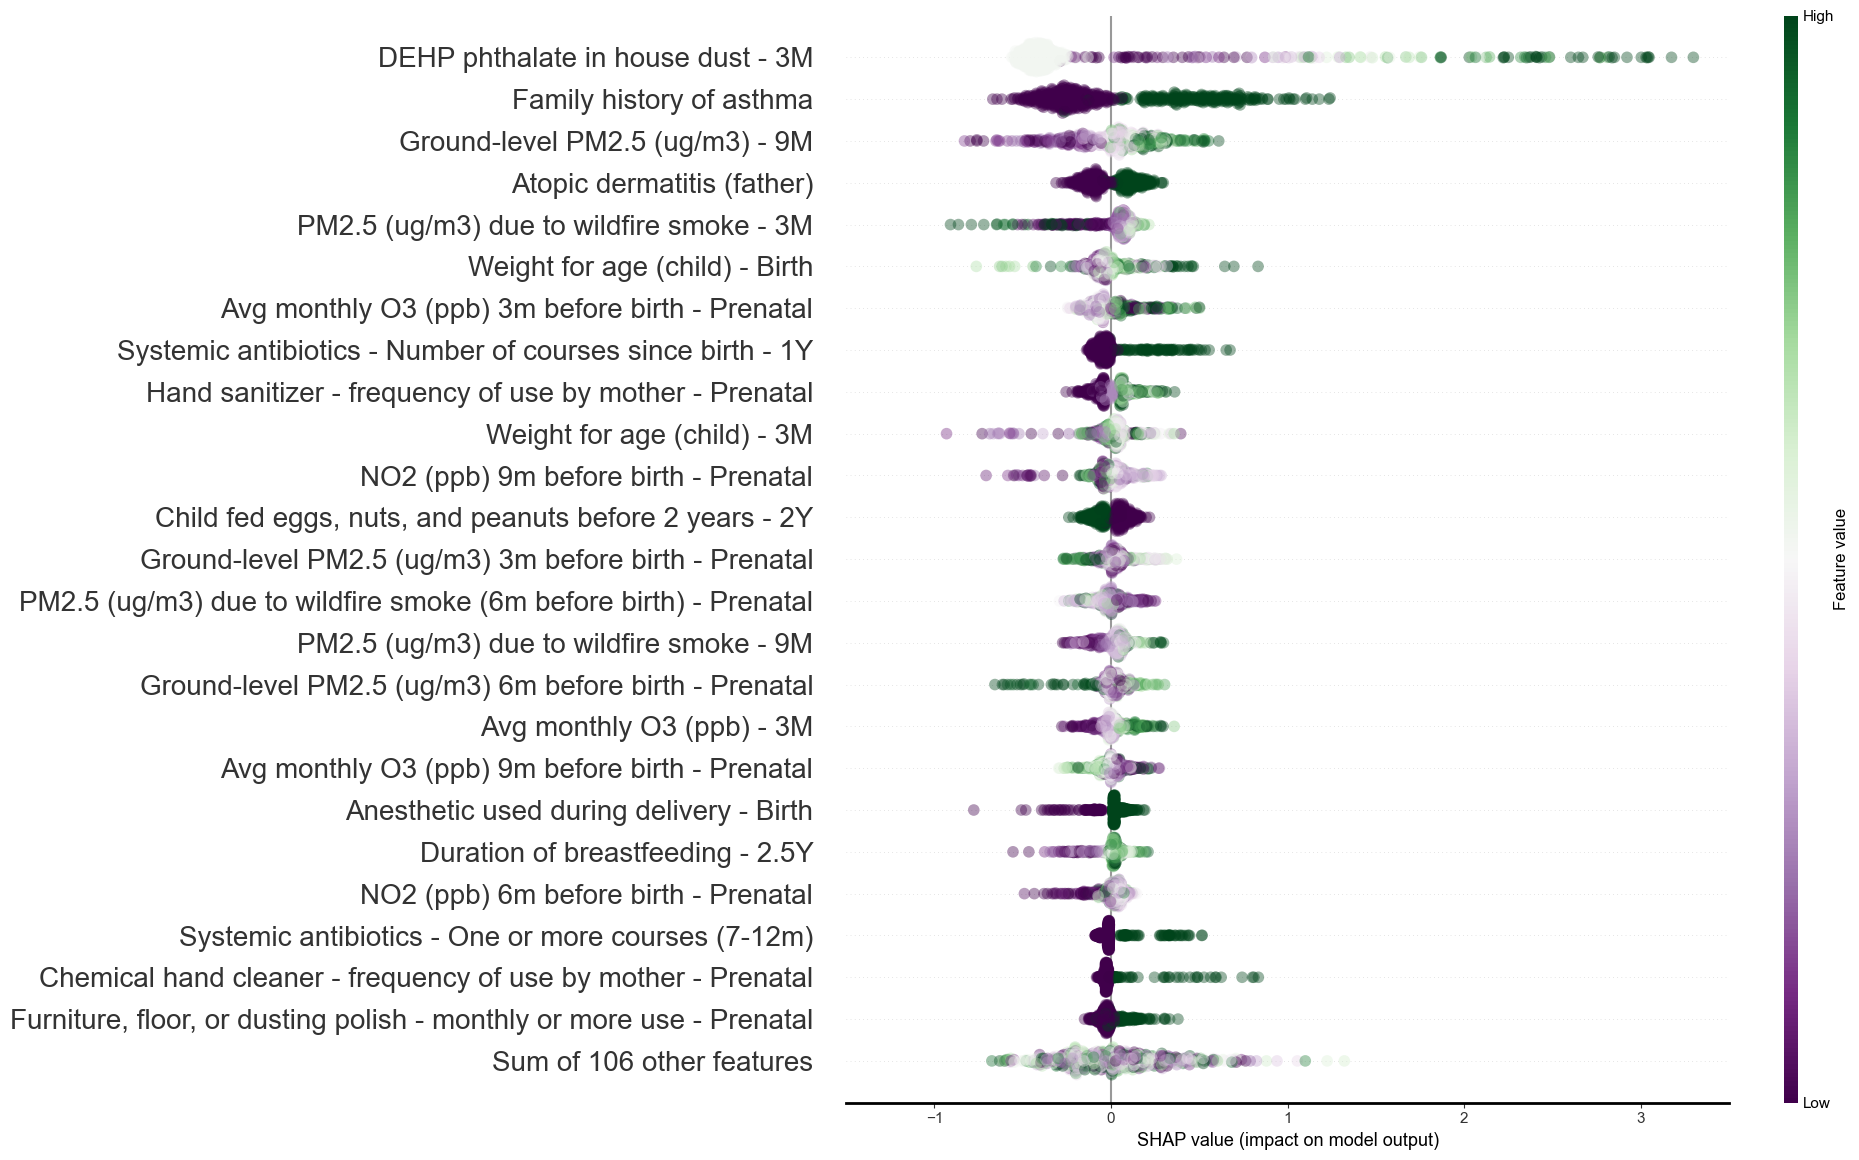

In [35]:
import shap
plt.rcParams['font.family'] = 'Arial'
explainer = shap.TreeExplainer(best_final_model)

shap_values = explainer(X_holdout_preprocessed)

# Limit to specific features

#shap_features_needed = ['PM25_annual_avg_18WK', 'O3_8H_2m_post_birth','NO2_annual_avg_18WK','PM25_annual_avg_3M','NO2_annual_avg_1Y','PM25_annual_avg_1Y']

#subset = shap_values[:, shap_features_needed]
subset = shap_values

shap.plots.beeswarm(subset, max_display=25, plot_size=(20, 12), s=70, color='PRGn',  alpha=0.4, show=False)

replacements = {
    "Family history of asthma - Prenatal": "Family history of asthma",
    "Atopic dermatitis (father) - Prenatal": "Atopic dermatitis (father)",
    "Gestational days at birth - Birth": "Gestational days at birth",
    "Anesthetic used during delivery - Birth": "Anesthetic used during delivery",
    "Stay duration in hospital after birth - Birth": "Stay duration in hospital after birth",
    "AD_Father": "Atopic dermatitis (father)",
    "frequency_of_use_of_hand_sanitizer_prenatal": "Hand sanitizer - frequency of use by mother - prenatal",
    "Hayfever_Mother": "Hayfever (mother)",
    "DTR_distance_to_secondary_highways_18WK": "Distance to nearest secondary highway (m) - Prenatal",
    "O3_8H_9m_post_birth": "Avg monthly O3 (ppb), rolling 8H - 9M",
    'UV_SEA_3m_pre - Birth': "VitD action spectrum-weighted UV levels 3m before birth - Prenatal",
    'PSS_36week_Moderate_Stress': "Perceived stress (mother) moderate - Prenatal",
    "monthly_furniture_floor_dusting_polish_use_prenatal":"Furniture, floor or dusting polish - monthly or more use - prenatal",
    "took_systemic_antibiotics_7_to_12_months":"Systemic antibiotics - One or more courses (7-12m)",
    "AQSMK_PM25_3m_post_birth":"PM2.5 (ug/m3) due to wildfire smoke - 3M",
    "AQSMK_PM25_9m_post_birth":"PM2.5 (ug/m3) due to wildfire smoke - 9M",
    "NO2_LUR_6m_pre_birth":"NO2 (ppb) 6m before birth - Prenatal",
    "Anesthetic_delivery":"Anesthetic used during delivery - Birth"
}

#     

# --- Modify y-axis labels ---
ax = plt.gca()
ax.set_xlim(-1.5, 3.5)  # Set your desired limits here
yticklabels = [t.get_text() for t in ax.get_yticklabels()]          # current labels
new_labels = [feature_to_description.get(lbl, lbl) for lbl in yticklabels]       # replace if in dict
new_labels = [replacements.get(label, label) for label in new_labels]
ax.set_yticklabels(new_labels, fontsize=20)                         # apply new labels

# Add black border around plot area only
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()

In [135]:
print(shap.__version__)

0.46.0


## Calculate SHAP interaction values - return top 25

In [36]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# reverse the order of yticklabels list
yticklabels.reverse()

# Calculate SHAP interaction values
print("Calculating SHAP interaction values...")
shap_interaction_values = explainer.shap_interaction_values(X_holdout_preprocessed)

# If binary classification, select positive class
if isinstance(shap_interaction_values, list):
    shap_interaction_values = shap_interaction_values[1]

# Extract the values array from shap_values if it's an Explanation object
if hasattr(shap_values, 'values'):
    shap_values_array = shap_values.values
else:
    shap_values_array = shap_values

# If binary classification and it's a list, get positive class
if isinstance(shap_values_array, list):
    shap_values_array = shap_values_array[1]


# Get indices for these features
feature_indices = [list(X_holdout_preprocessed.columns).index(f) for f in yticklabels if f in X_holdout_preprocessed.columns]
valid_features = [f for f in yticklabels if f in X_holdout_preprocessed.columns]

# Extract interaction effects for important features only
n_features = len(feature_indices)
interaction_matrix = np.zeros((n_features, n_features))

print(f"Processing {n_features} features...")
for i, idx_i in enumerate(feature_indices):
    for j, idx_j in enumerate(feature_indices):
        if i != j:  # Skip diagonal (self-interactions)
            # Mean absolute interaction effect
            interaction_matrix[i, j] = np.abs(
                shap_interaction_values[:, idx_i, idx_j]
            ).mean()

# Create DataFrame for easy viewing
interaction_df = pd.DataFrame(
    interaction_matrix,
    index=valid_features,
    columns=valid_features
)

# Get top interactions (upper triangle only to avoid duplicates)
top_interactions = []
for i in range(n_features):
    for j in range(i+1, n_features):
        top_interactions.append({
            'Feature 1': interaction_df.index[i],
            'Feature 2': interaction_df.columns[j],
            'Mean Abs Interaction': interaction_matrix[i, j],
            'Interaction Strength': interaction_matrix[i, j] / (
                np.abs(shap_values_array[:, feature_indices[i]]).mean() + 
                np.abs(shap_values_array[:, feature_indices[j]]).mean()
            )  # Normalized by main effects
        })

top_interactions_df = pd.DataFrame(top_interactions).sort_values(
    'Mean Abs Interaction', ascending=False
)

# Display top 20 interactions
print("\n=== Top 25 Feature Interactions ===")
print(top_interactions_df.head(25).to_string(index=False))

# Save to CSV for reference
top_interactions_df.to_csv('output/top_feature_interactions.csv', index=False)
print("\nFull results saved to 'output/top_feature_interactions.csv'")



Calculating SHAP interaction values...
Processing 24 features...

=== Top 25 Feature Interactions ===
                Feature 1                                           Feature 2  Mean Abs Interaction  Interaction Strength
log_dehp_in_house_dust_3m                                   Weight_for_age_0m              0.066065              0.091346
log_dehp_in_house_dust_3m                                NO2_LUR_9m_pre_birth              0.048072              0.068698
log_dehp_in_house_dust_3m                                   Weight_for_age_3m              0.047630              0.068016
    family_asthma_history                               PM25_PM_9m_post_birth              0.046245              0.086699
    family_asthma_history                                PM25_PM_3m_pre_birth              0.041136              0.097960
    family_asthma_history                             AQSMK_PM25_6m_pre_birth              0.036747              0.088131
       O3_8H_3m_pre_birth                   

In [137]:
top_interactions_df

,Feature 1,Feature 2,Mean Abs Interaction,Interaction Strength
4,log_dehp_in_house_dust_3m,Weight_for_age_0m,0.066065,0.091346
9,log_dehp_in_house_dust_3m,NO2_LUR_9m_pre_birth,0.048072,0.068698
8,log_dehp_in_house_dust_3m,Weight_for_age_3m,0.047630,0.068016
23,family_asthma_history,PM25_PM_9m_post_birth,0.046245,0.086699
33,family_asthma_history,PM25_PM_3m_pre_birth,0.041136,0.097960
34,family_asthma_history,AQSMK_PM25_6m_pre_birth,0.036747,0.088131
123,O3_8H_3m_pre_birth,num_systemic_antibotics_birth_1y,0.032350,0.184844
42,family_asthma_history,took_systemic_antibiotics_7_to_12_months,0.031219,0.077293
25,family_asthma_history,AQSMK_PM25_3m_post_birth,0.031149,0.067477
36,family_asthma_history,PM25_PM_6m_pre_birth,0.027667,0.066497


## Figure 5b: Interaction heatmap

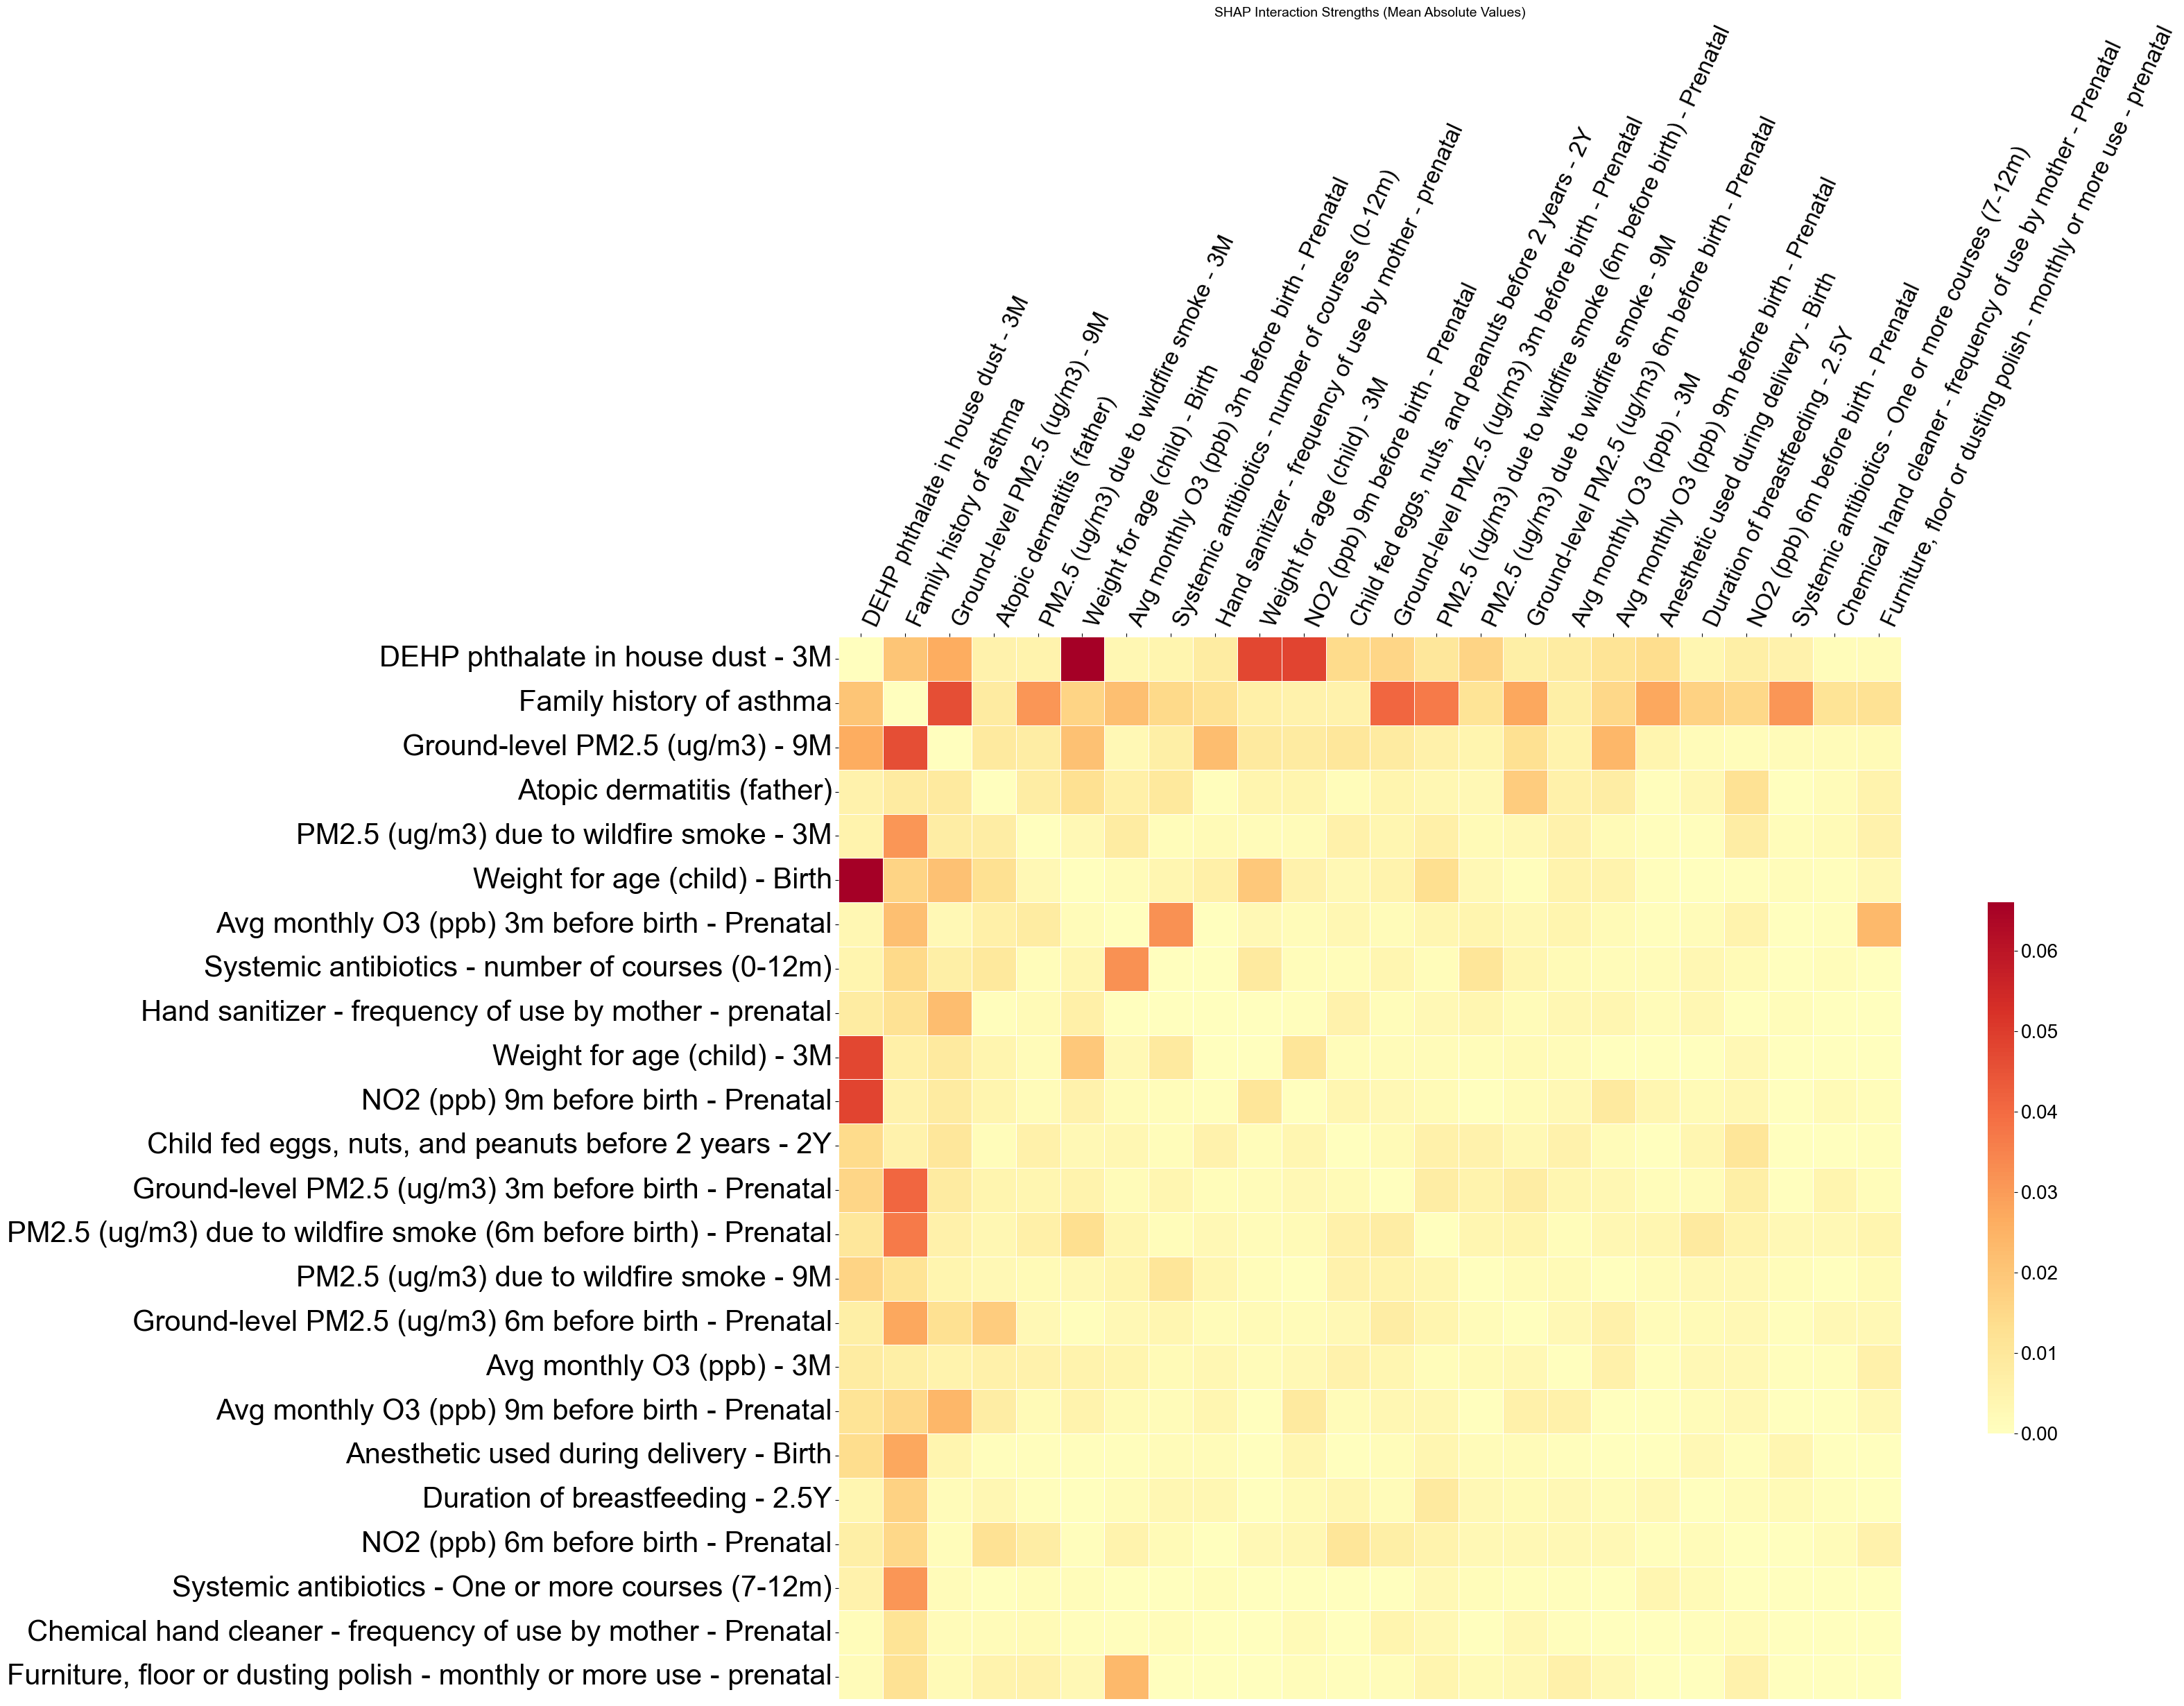


Heatmap saved to Figure_6b_SHAP_interaction_heatmap.png'


In [173]:
# Visualize as heatmap
plt.figure(figsize=(35, 25))
sns.heatmap(interaction_df, annot=False, cmap='RdYlBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.5})
plt.title('SHAP Interaction Strengths (Mean Absolute Values)', fontsize=14)
feature_to_description.update(replacements)
# Get current labels and map them to descriptions
x_labels = [feature_to_description.get(label.get_text(), label.get_text()) 
            for label in plt.gca().get_xticklabels()]
y_labels = [feature_to_description.get(label.get_text(), label.get_text()) 
            for label in plt.gca().get_yticklabels()]

# Set the new labels
plt.gca().set_xticklabels(x_labels, rotation=45, ha='right', fontsize=18)
plt.gca().set_yticklabels(y_labels, rotation=0, fontsize=18)





ax = plt.gca()

# Move x-axis to top
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

ax.set_xticklabels(x_labels, rotation=65, ha='left', fontsize=24)
ax.set_yticklabels(y_labels, rotation=0, fontsize=30)



plt.tight_layout()
plt.savefig('figures/Figure_6b_SHAP_interaction_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHeatmap saved to Figure_6b_SHAP_interaction_heatmap.png'")

## Figure 5c: 2D partial dependence plot for family history of asthma versus average monthly O3 (ppb) at 3 months prior to birth

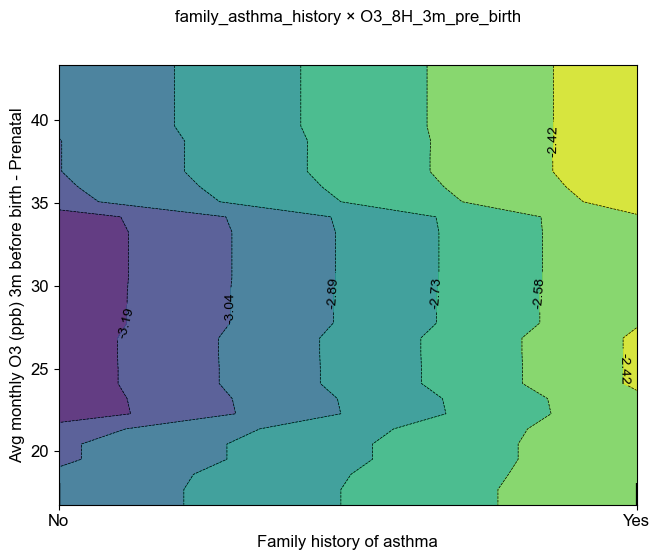

In [168]:


fig, ax = plt.subplots(figsize=(7, 6))

display = PartialDependenceDisplay.from_estimator(
    best_final_model,                           # your fitted model
    X_holdout_preprocessed,          # feature matrix
    features=[('family_asthma_history', 'O3_8H_3m_pre_birth')],
    kind='average',                  # or 'individual' for ICE curves
    grid_resolution=30,              # number of grid points per axis
    contour_kw={
        'cmap': 'viridis',  # Explicitly set viridis
        'alpha': 0.85
    },
    ax=ax,
    
)

# Access the plot axes
plot_ax = display.axes_[0, 0]
plot_ax.set_xticks([0, 1])
plot_ax.set_xticklabels(['No', 'Yes'])

# Set custom tick labels for x-axis (frequency variable)

# Update labels
plot_ax.set_xlabel(feature_to_description.get('family_asthma_history'),fontsize=12)
plot_ax.set_ylabel(feature_to_description.get('O3_8H_3m_pre_birth'), fontsize=12)
plot_ax.set_title("family_asthma_history × O3_8H_3m_pre_birth\n\n", fontsize=12)
plot_ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

## Supplementary figure 16: 2D partial dependence plot for Number of systemic antibiotic courses (birth-1y) versus average monthly O3 (ppb) levels measured 3 months prior to birth

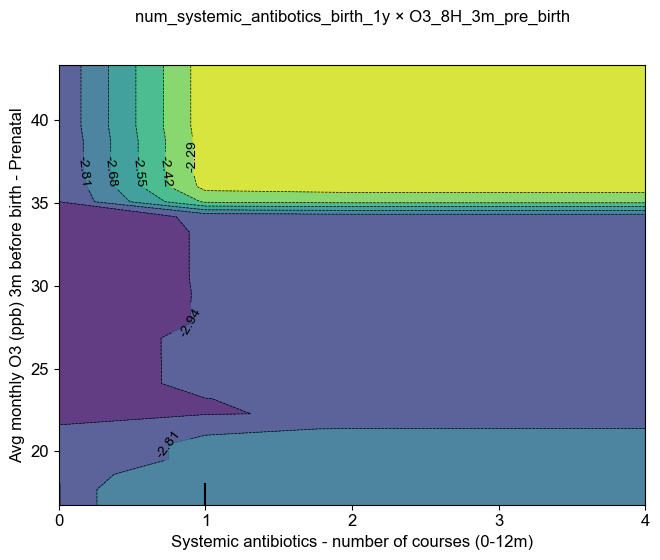

In [176]:


fig, ax = plt.subplots(figsize=(7, 6))

display = PartialDependenceDisplay.from_estimator(
    best_final_model,                           # your fitted model
    X_holdout_preprocessed,          # feature matrix
    features=[('num_systemic_antibotics_birth_1y', 'O3_8H_3m_pre_birth')],
    kind='average',                  # or 'individual' for ICE curves
    grid_resolution=30,              # number of grid points per axis
    contour_kw={
        'cmap': 'viridis',  # Explicitly set viridis
        'alpha': 0.85
    },
    ax=ax,
    
)

# Access the plot axes
plot_ax = display.axes_[0, 0]
plot_ax.set_xticks([0, 1,2,3,4])
#plot_ax.set_xticklabels(['No', 'Yes'])

# Set custom tick labels for x-axis (frequency variable)

# Update labels
plot_ax.set_xlabel(feature_to_description.get('num_systemic_antibotics_birth_1y'),fontsize=12)
plot_ax.set_ylabel(feature_to_description.get('O3_8H_3m_pre_birth'), fontsize=12)
plot_ax.set_title("num_systemic_antibotics_birth_1y × O3_8H_3m_pre_birth\n\n", fontsize=12)
plot_ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

In [ ]:
tmp = X_holdout_preprocessed[~X_holdout_preprocessed['O3_8H_9m_post_birth'].isna()]
#tmp = tmp[tmp['O3_8H_9m_post_birth']<=40]
tmp = tmp[tmp['took_systemic_antibiotics_7_to_12_months']==1]
#tmp = tmp[tmp['definite_asthma_5y']==1]
tmp[['O3_8H_9m_post_birth','took_systemic_antibiotics_7_to_12_months']]


## Figure 5c: 2D partial dependence plot for family history of asthma versus ground level PM2.5 (ug/m3) at 9 months post birth

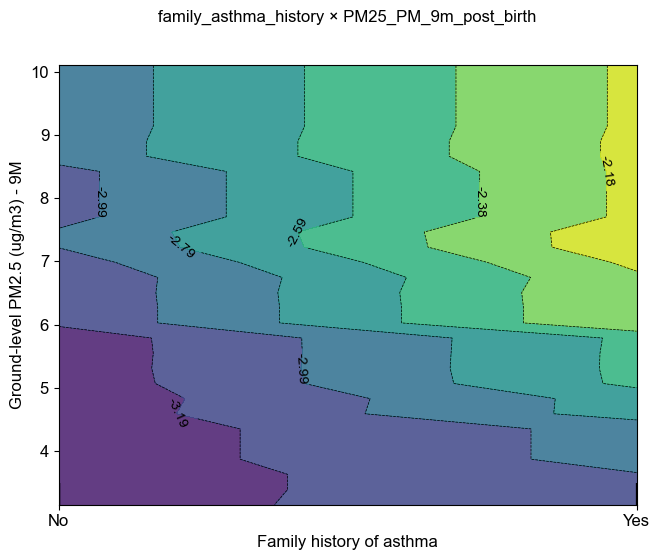

In [158]:


fig, ax = plt.subplots(figsize=(7, 6))

display = PartialDependenceDisplay.from_estimator(
    best_final_model,                           # your fitted model
    X_holdout_preprocessed,          # feature matrix
    features=[('family_asthma_history', 'PM25_PM_9m_post_birth')],
    kind='average',                  # or 'individual' for ICE curves
    grid_resolution=30,              # number of grid points per axis
    contour_kw={
        'cmap': 'viridis',  # Explicitly set viridis
        'alpha': 0.85
    },
    ax=ax,
    
)

# Access the plot axes
plot_ax = display.axes_[0, 0]
plot_ax.set_xticks([0, 1])
plot_ax.set_xticklabels(['No', 'Yes'])

# Set custom tick labels for x-axis (frequency variable)

# Update labels
plot_ax.set_xlabel(feature_to_description.get('family_asthma_history'),fontsize=12)
plot_ax.set_ylabel(feature_to_description.get('PM25_PM_9m_post_birth'), fontsize=12)
plot_ax.set_title("family_asthma_history × PM25_PM_9m_post_birth\n\n", fontsize=12)
plot_ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

## Figure 5c: 2D partial dependence plot for family history of asthma versus frequency of chemical hand cleaner use by mother during pregnancy (reported at 18th week)

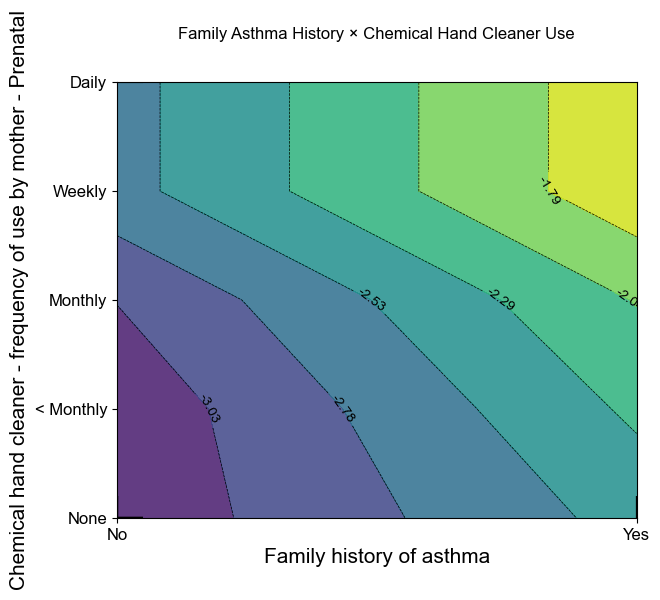

In [144]:
# --- 2D Partial Dependence Plot ---
fig, ax = plt.subplots(figsize=(7, 6))

display = PartialDependenceDisplay.from_estimator(
    best_final_model,                           # your fitted model
    X_holdout_preprocessed,          # feature matrix
    features=[('family_asthma_history', 'frequency_of_use_of_chemical_hand_cleaner_prenatal')],
    kind='average',                  # or 'individual' for ICE curves
    grid_resolution=30,              # number of grid points per axis
    contour_kw={
        'cmap': 'viridis',  # Explicitly set viridis
        'alpha': 0.85
    },
    ax=ax
)

# Access the plot axes
plot_ax = display.axes_[0, 0]
# Set custom tick labels for x-axis (frequency variable)
plot_ax.set_yticks([0, 1, 2, 3, 4])
plot_ax.set_yticklabels(['None', '< Monthly', 'Monthly', 'Weekly', 'Daily'])

plot_ax.set_xticks([0, 1])
plot_ax.set_xticklabels(['No', 'Yes'])


# Update labels - use set_xlabel for x-axis and set_ylabel for y-axis
plot_ax.set_xlabel(feature_to_description.get('family_asthma_history'), fontsize=15)
plot_ax.set_ylabel(feature_to_description.get('frequency_of_use_of_chemical_hand_cleaner_prenatal'), fontsize=15)
plot_ax.set_title("Family Asthma History × Chemical Hand Cleaner Use\n\n", fontsize=12)
plot_ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

## Figure 5c: 2D partial dependence plot for family history of asthma versus frequency of hand sanitizer use by mother during pregnancy (reported at 18th week)

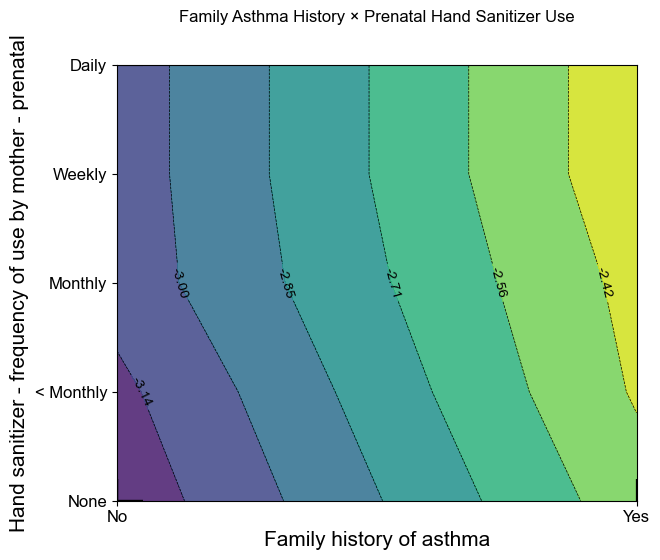

In [145]:


# --- 2D Partial Dependence Plot ---
fig, ax = plt.subplots(figsize=(7, 6))

display = PartialDependenceDisplay.from_estimator(
    best_final_model,                           # your fitted model
    X_holdout_preprocessed,          # feature matrix
    features=[('family_asthma_history', 'frequency_of_use_of_hand_sanitizer_prenatal')],
    kind='average',                  # or 'individual' for ICE curves
    grid_resolution=30,              # number of grid points per axis
    contour_kw={
        'cmap': 'viridis',  # Explicitly set viridis
        'alpha': 0.85
    },
    ax=ax
)

# Access the plot axes
plot_ax = display.axes_[0, 0]
# Set custom tick labels for x-axis (frequency variable)
plot_ax.set_yticks([0, 1, 2, 3, 4])
plot_ax.set_yticklabels(['None', '< Monthly', 'Monthly', 'Weekly', 'Daily'])

plot_ax.set_xticks([0, 1])
plot_ax.set_xticklabels(['No', 'Yes'])


# Update labels - use set_xlabel for x-axis and set_ylabel for y-axis
plot_ax.set_xlabel(feature_to_description.get('family_asthma_history'), fontsize=15)
plot_ax.set_ylabel(feature_to_description.get('frequency_of_use_of_hand_sanitizer_prenatal'), fontsize=15)
plot_ax.set_title("Family Asthma History × Prenatal Hand Sanitizer Use\n\n", fontsize=12)
plot_ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()


## Figure 5c: 2D partial dependence plot for family history of asthma versus average monthly NO2 (ppb) at 6m prior to birth

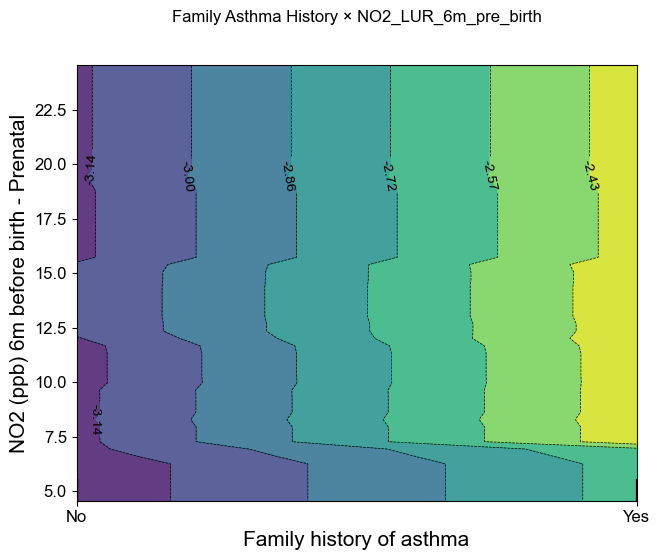

In [156]:
# --- 2D Partial Dependence Plot ---
from sklearn.inspection import PartialDependenceDisplay


fig, ax = plt.subplots(figsize=(7, 6))

display = PartialDependenceDisplay.from_estimator(
    best_final_model,                           # your fitted model
    X_holdout_preprocessed,          # feature matrix
    features=[('family_asthma_history', 'NO2_LUR_6m_pre_birth')],
    kind='average',                  # or 'individual' for ICE curves
    grid_resolution=60,              # number of grid points per axis
    contour_kw={
        'cmap': 'viridis',  # Explicitly set viridis
        'alpha': 0.85
    },
    ax=ax
)

# Access the plot axes
plot_ax = display.axes_[0, 0]


plot_ax.set_xticks([0, 1])
plot_ax.set_xticklabels(['No', 'Yes'])


# Update labels - use set_xlabel for x-axis and set_ylabel for y-axis
plot_ax.set_xlabel(feature_to_description.get('family_asthma_history'), fontsize=15)
plot_ax.set_ylabel(feature_to_description.get('NO2_LUR_6m_pre_birth'), fontsize=15)
plot_ax.set_title("Family Asthma History × NO2_LUR_6m_pre_birth\n\n", fontsize=12)
plot_ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()